In [1]:
### Hayden Gallo
### Bucci Lab 
### 9/23/25

### Testing gLV/MDSINE_FBA on Western Diet cohort mice of Kennedy et al. 2025

import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
import sys
import os
import openpyxl
import gurobipy

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
import arviz as az

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess

### script for running glv_dfba inference
from helper_functions import *
import argparse
import re

from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import json
import logging
from scipy.stats import pearsonr, spearmanr

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#################################################################################################################################################################
### this is used to surpress all logging from loading in the kbase models with cobra, such that they don't get added to the glv_fba log file and overcrowd it ### 
logging.getLogger("cobra").setLevel(logging.ERROR)
#################################################################################################################################################################

In [4]:
### subject with abundance data
subject_to_plot = 1512#1946#1516#1512
### subject to predict, subject with metabolomics data
subject_to_predict = 1515#1942#1502#1515
### Set test num
test_num = 25
### set time scaler
time_scaler = 24#96#192#24
### Total time steps
total_time_steps = 408
###
notes = 'constraining to mets of interest and decay term of 1-1/24, host has been limited to upper bound of 0.0'

In [5]:
## ok now need to reconstruct the time series basically 

### need to load in all of the processed_data 
# Make the data and validation Study objects

processed_data = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_WD_abx_09_15_25')

tsv_files = sorted(processed_data.glob('*.tsv'))
tsv_files = {f.stem : f for f in tsv_files}


with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)
    print(bigg_to_modelseed)




{'h2o': 'cpd00001', 'oh1': 'cpd00001', 'atp': 'cpd00002', 'nad': 'cpd00003', 'nadh': 'cpd00004', 'nadph': 'cpd00005', 'nadp': 'cpd00006', 'o2': 'cpd00007', 'adp': 'cpd00008', 'pi': 'cpd00009', 'coa': 'cpd00010', 'co2': 'cpd00011', 'ppi': 'cpd00012', 'nh3': 'cpd00013', 'nh4': 'cpd00013', 'udp': 'cpd00014', 'fad': 'cpd00015', 'pydx5p': 'cpd00016', 'amet': 'cpd00017', 'amp': 'cpd00018', 'ahcys': 'cpd00019', 'pyr': 'cpd00020', 'accoa': 'cpd00022', 'glu__L': 'cpd00023', 'akg': 'cpd00024', 'h2o2': 'cpd00025', 'udpg': 'cpd00026', 'glc__D': 'cpd00027', 'pheme': 'cpd00028', 'ac': 'cpd00029', 'mn2': 'cpd00030', 'gdp': 'cpd00031', 'oaa': 'cpd00032', 'gly': 'cpd00033', 'zn2': 'cpd00034', 'ala__L': 'cpd00035', 'succ': 'cpd00036', 'uacgam': 'cpd00037', 'gtp': 'cpd00038', 'lys__L': 'cpd00039', 'glx': 'cpd00040', 'asp__L': 'cpd00041', 'gthrd': 'cpd00042', 'udpgal': 'cpd00043', 'paps': 'cpd00044', 'pap': 'cpd00045', 'cmp': 'cpd00046', 'for': 'cpd00047', 'so4': 'cpd00048', 'fmn': 'cpd00050', 'arg__L': '

In [6]:
counts = pd.read_csv(tsv_files['counts'], delimiter='\t', index_col=0)
metadata = pd.read_csv(tsv_files['metadata'], delimiter='\t', index_col=0)
perturbations = pd.read_csv(tsv_files['perturbations'], delimiter='\t', index_col=0)
qpcr = pd.read_csv(tsv_files['qpcr'], delimiter='\t', index_col=0)
taxonomy = pd.read_csv(tsv_files['taxonomy'], delimiter='\t', index_col=0)





In [7]:
### Load in diet data that will be applied in intervals 

########################
### CHANGE FILE PATH ###
########################


WD_diet = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/WD_w_MS_additions.csv', index_col=0)

## Multiply by 5g over 12 hours
WD_diet['fluxValue'] = ((5/time_scaler)*WD_diet['fluxValue'])
WD_diet.head()

,fluxValue,reaction
0,0.0000,EX_cpd35610_b
1,0.0000,EX_cpd01242_b
2,0.0000,EX_cpd01293_b
3,0.0000,EX_cpd00035_b
4,0.0006,EX_cpd01055_b


In [8]:
### Load in metabolomics data 

metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)
metabolomics_data.head()

,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
0,HF1114,0.135,0.272,0.199,6.991,0.049,12.191,0.0,0.178,0.000,...,0.248,0.791,0.000,3.766,0.493,0.043,7.512,0.084,2.029,0.581
1,HF1115,0.263,0.285,0.305,11.053,0.069,15.784,0.0,0.243,0.520,...,0.423,6.104,0.064,1.350,1.086,0.056,8.391,0.139,1.919,1.908
2,HF1119,0.212,0.059,0.132,2.192,0.042,0.139,0.0,0.073,0.409,...,0.132,0.587,0.037,0.110,0.454,0.000,8.760,0.038,0.195,0.020
3,HF1120,0.528,0.067,0.122,1.459,0.030,0.175,0.0,0.062,0.000,...,0.105,0.520,0.307,0.400,0.431,0.023,14.081,0.049,0.099,0.027
4,HF1124,0.147,0.381,0.637,15.682,0.035,9.139,0.0,0.258,0.000,...,0.529,0.912,0.013,6.306,0.881,0.471,1.399,0.088,0.637,0.332


In [9]:
### load in metabolomics metadata

metabolomics_metadata_raw = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/metabolomics_meta.csv', index_col=0)
# filtered metabolomics metadata for subject XX initial sample 
metabolomics_metadata = metabolomics_metadata_raw.copy()
metabolomics_metadata = metabolomics_metadata[(metabolomics_metadata['Mouse'] == float(subject_to_predict)) & (metabolomics_metadata['Rec_day_adj'] == -3)]
metabolomics_metadata.index.tolist()

['HF1128']

In [10]:
### load in refseq to agora dataframe

## utilizing updated refseq file


########################
### CHANGE FILE PATH ###
########################


refseq_to_agora_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/refseq_to_agora_df_WD_cohorts_manual_curation_09_17_25.tsv', index_col=0, sep = '\t')
refseq_to_agora_df.head()


,Accession,Species,Strain,Agora_Name,Assembly_Name,RefSeq_Category,Assembly_Level
ASV_string,,,,,,,
14ac4eaad5b4e2ff3c071832e0fd4229,GCF_000771225.1,Bifidobacterium_pseudolongum,none,Bifidobacterium_pseudolongum_none,DSM-20099,na,Contig
4cc9a4b9aaa3ee9a5c14cc27551a6844,GCF_000393355.1,Enterococcus_faecalis,D173,Enterococcus_faecalis_D173,Ente_faec_D173_V1,na,Scaffold
5de4dd141b21005d8b5e70319a3daed1,GCF_000287935.1,Stenotrophomonas_maltophilia,Ab55555,Stenotrophomonas_maltophilia_Ab55555,Sten_malt_Ab55555_V1,na,Scaffold
5f2f1477e1b97c1e2890599a0df38fdf,GCF_000025045.1,Lactococcus_lactis,KF147,Lactococcus_lactis_KF147,ASM2504v1,na,Complete Genome
669299212a42d345732463ba7adac099,GCF_000092025.1,Agrobacterium_fabrum,none,Agrobacterium_fabrum_none,ASM9202v1,reference genome,Complete Genome


In [11]:
### since i am going with daily resolution need to load in that data for determining initial abundances and the rates of change 

# nevermind bihourly after i figured out the smoothing
MDSINE_filter_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_WD_abx_09_15_25/WD_hourly_filtering/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
bi_hourly_resolution_latent_traj = pd.read_csv(MDSINE_filter_path, delimiter='\t', index_col=0)
bi_hourly_resolution_latent_traj

,0.0,0.041666666666666664,0.08333333333333333,0.125,0.16666666666666666,0.20833333333333331,0.25,0.29166666666666663,0.3333333333333333,0.375,...,16.625,16.666666666666664,16.708333333333332,16.75,16.791666666666664,16.833333333333332,16.875,16.916666666666664,16.958333333333332,17.0
14ac4eaad5b4e2ff3c071832e0fd4229,2.473784e+08,2.942887e+08,3.454163e+08,4.001219e+08,4.575551e+08,5.166741e+08,5.762777e+08,6.350490e+08,6.916090e+08,7.445751e+08,...,1.816221e+09,1.585101e+09,1.365942e+09,1.161833e+09,9.750769e+08,8.071681e+08,6.588149e+08,5.300050e+08,4.201023e+08,3.279655e+08
36173253c63ad49abc12361a0b3304eb,7.518214e+07,1.155256e+08,1.729777e+08,2.525254e+08,3.596450e+08,4.999730e+08,6.788432e+08,9.007146e+08,1.168535e+09,1.483110e+09,...,1.526043e+02,1.550917e+02,1.577619e+02,1.606251e+02,1.636926e+02,1.669766e+02,1.704901e+02,1.742474e+02,1.782639e+02,1.825565e+02
3936cc515320e9f29d81ffeaa92718e8,7.790014e+07,1.053253e+08,1.395861e+08,1.814119e+08,2.313135e+08,2.894962e+08,3.557826e+08,4.295543e+08,5.097210e+08,5.947246e+08,...,3.816840e+02,4.021373e+02,4.248573e+02,4.501340e+02,4.783022e+02,5.097501e+02,5.449281e+02,5.843610e+02,6.286611e+02,6.785458e+02
48ceb9d423d095a3e48cdb3da1da8823,1.191175e+08,1.586514e+08,2.069570e+08,2.645455e+08,3.315261e+08,4.075153e+08,4.915731e+08,5.821804e+08,6.772632e+08,7.742672e+08,...,1.466256e+02,1.441763e+02,1.415588e+02,1.387780e+02,1.358391e+02,1.327488e+02,1.295144e+02,1.261440e+02,1.226469e+02,1.190331e+02
4a917215bed7e87c535e2cc8c12bd802,6.213979e+02,6.021995e+02,5.831021e+02,5.641630e+02,5.454341e+02,5.269620e+02,5.087881e+02,4.909486e+02,4.734753e+02,4.563953e+02,...,6.870670e+02,7.490491e+02,8.189687e+02,8.980315e+02,9.876537e+02,1.089503e+03,1.205549e+03,1.338123e+03,1.489992e+03,1.664452e+03
4b83c4579601a3e7125fe207b4c1e2d8,1.185058e+08,1.616269e+08,2.161306e+08,2.834850e+08,3.648688e+08,4.610165e+08,5.720678e+08,6.974400e+08,8.357375e+08,9.847147e+08,...,7.236452e+07,7.230612e+07,7.199452e+07,7.142495e+07,7.059552e+07,6.950742e+07,6.816501e+07,6.657591e+07,6.475098e+07,6.270429e+07
4cc9a4b9aaa3ee9a5c14cc27551a6844,3.131183e+02,3.126028e+02,3.122711e+02,3.121166e+02,3.121329e+02,3.123142e+02,3.126547e+02,3.131491e+02,3.137924e+02,3.145797e+02,...,5.118377e+10,5.676974e+10,6.323462e+10,7.074082e+10,7.948512e+10,8.970688e+10,1.016981e+11,1.158166e+11,1.325018e+11,1.522963e+11
5de4dd141b21005d8b5e70319a3daed1,9.882504e+02,8.874289e+02,8.001944e+02,7.244637e+02,6.585077e+02,6.008867e+02,5.503975e+02,5.060312e+02,4.669395e+02,4.324060e+02,...,2.944192e+02,2.995633e+02,3.050032e+02,3.107568e+02,3.168431e+02,3.232830e+02,3.300984e+02,3.373133e+02,3.449533e+02,3.530463e+02
5f2f1477e1b97c1e2890599a0df38fdf,6.090779e+08,6.488177e+08,6.861125e+08,7.203507e+08,7.509678e+08,7.774637e+08,7.994158e+08,8.164909e+08,8.284534e+08,8.351697e+08,...,8.129093e+09,7.888709e+09,7.651110e+09,7.416448e+09,7.184870e+09,6.956516e+09,6.731515e+09,6.509994e+09,6.292068e+09,6.077847e+09
669299212a42d345732463ba7adac099,6.355226e+01,6.605585e+01,6.861440e+01,7.122686e+01,7.389206e+01,7.660869e+01,7.937535e+01,8.219048e+01,8.505243e+01,8.795939e+01,...,7.267119e+08,7.562617e+08,7.892175e+08,8.259564e+08,8.669104e+08,9.125754e+08,9.635219e+08,1.020407e+09,1.083989e+09,1.155146e+09


In [12]:
### filter metabolomics data by initial sample

metabolomics_data_initial_sub = metabolomics_data[metabolomics_data['SampleName'] == metabolomics_metadata.index.tolist()[0]]
#init_metabolite_sample


In [13]:
for i in range(0, len(bi_hourly_resolution_latent_traj.columns)-1):

  if i == 0:
    base_array = np.linspace(bi_hourly_resolution_latent_traj.iloc[:,i], bi_hourly_resolution_latent_traj.iloc[:,i+1], 2)
  else:
    temp_array = np.linspace(bi_hourly_resolution_latent_traj.iloc[:,i], bi_hourly_resolution_latent_traj.iloc[:,i+1], 2)[1:,:]
    base_array = np.concatenate((base_array, temp_array))

In [14]:
abun_df = pd.DataFrame(base_array.T, index=bi_hourly_resolution_latent_traj.index)
abun_df

,0,1,2,3,4,5,6,7,8,9,...,399,400,401,402,403,404,405,406,407,408
14ac4eaad5b4e2ff3c071832e0fd4229,2.473784e+08,2.942887e+08,3.454163e+08,4.001219e+08,4.575551e+08,5.166741e+08,5.762777e+08,6.350490e+08,6.916090e+08,7.445751e+08,...,1.816221e+09,1.585101e+09,1.365942e+09,1.161833e+09,9.750769e+08,8.071681e+08,6.588149e+08,5.300050e+08,4.201023e+08,3.279655e+08
36173253c63ad49abc12361a0b3304eb,7.518214e+07,1.155256e+08,1.729777e+08,2.525254e+08,3.596450e+08,4.999730e+08,6.788432e+08,9.007146e+08,1.168535e+09,1.483110e+09,...,1.526043e+02,1.550917e+02,1.577619e+02,1.606251e+02,1.636926e+02,1.669766e+02,1.704901e+02,1.742474e+02,1.782639e+02,1.825565e+02
3936cc515320e9f29d81ffeaa92718e8,7.790014e+07,1.053253e+08,1.395861e+08,1.814119e+08,2.313135e+08,2.894962e+08,3.557826e+08,4.295543e+08,5.097210e+08,5.947246e+08,...,3.816840e+02,4.021373e+02,4.248573e+02,4.501340e+02,4.783022e+02,5.097501e+02,5.449281e+02,5.843610e+02,6.286611e+02,6.785458e+02
48ceb9d423d095a3e48cdb3da1da8823,1.191175e+08,1.586514e+08,2.069570e+08,2.645455e+08,3.315261e+08,4.075153e+08,4.915731e+08,5.821804e+08,6.772632e+08,7.742672e+08,...,1.466256e+02,1.441763e+02,1.415588e+02,1.387780e+02,1.358391e+02,1.327488e+02,1.295144e+02,1.261440e+02,1.226469e+02,1.190331e+02
4a917215bed7e87c535e2cc8c12bd802,6.213979e+02,6.021995e+02,5.831021e+02,5.641630e+02,5.454341e+02,5.269620e+02,5.087881e+02,4.909486e+02,4.734753e+02,4.563953e+02,...,6.870670e+02,7.490491e+02,8.189687e+02,8.980315e+02,9.876537e+02,1.089503e+03,1.205549e+03,1.338123e+03,1.489992e+03,1.664452e+03
4b83c4579601a3e7125fe207b4c1e2d8,1.185058e+08,1.616269e+08,2.161306e+08,2.834850e+08,3.648688e+08,4.610165e+08,5.720678e+08,6.974400e+08,8.357375e+08,9.847147e+08,...,7.236452e+07,7.230612e+07,7.199452e+07,7.142495e+07,7.059552e+07,6.950742e+07,6.816501e+07,6.657591e+07,6.475098e+07,6.270429e+07
4cc9a4b9aaa3ee9a5c14cc27551a6844,3.131183e+02,3.126028e+02,3.122711e+02,3.121166e+02,3.121329e+02,3.123142e+02,3.126547e+02,3.131491e+02,3.137924e+02,3.145797e+02,...,5.118377e+10,5.676974e+10,6.323462e+10,7.074082e+10,7.948512e+10,8.970688e+10,1.016981e+11,1.158166e+11,1.325018e+11,1.522963e+11
5de4dd141b21005d8b5e70319a3daed1,9.882504e+02,8.874289e+02,8.001944e+02,7.244637e+02,6.585077e+02,6.008867e+02,5.503975e+02,5.060312e+02,4.669395e+02,4.324060e+02,...,2.944192e+02,2.995633e+02,3.050032e+02,3.107568e+02,3.168431e+02,3.232830e+02,3.300984e+02,3.373133e+02,3.449533e+02,3.530463e+02
5f2f1477e1b97c1e2890599a0df38fdf,6.090779e+08,6.488177e+08,6.861125e+08,7.203507e+08,7.509678e+08,7.774637e+08,7.994158e+08,8.164909e+08,8.284534e+08,8.351697e+08,...,8.129093e+09,7.888709e+09,7.651110e+09,7.416448e+09,7.184870e+09,6.956516e+09,6.731515e+09,6.509994e+09,6.292068e+09,6.077847e+09
669299212a42d345732463ba7adac099,6.355226e+01,6.605585e+01,6.861440e+01,7.122686e+01,7.389206e+01,7.660869e+01,7.937535e+01,8.219048e+01,8.505243e+01,8.795939e+01,...,7.267119e+08,7.562617e+08,7.892175e+08,8.259564e+08,8.669104e+08,9.125754e+08,9.635219e+08,1.020407e+09,1.083989e+09,1.155146e+09


In [15]:
rate_array = np.zeros((17,abun_df.shape[1]-1))

In [16]:
for i in range(0,(len(abun_df.columns)-1)):

    rate_array[:,i] = (abun_df.iloc[:,i+1]/abun_df.iloc[:,i])-1

In [17]:
rate_df = pd.DataFrame(rate_array)

In [18]:
rate_df.index = bi_hourly_resolution_latent_traj.index
#test_df.index = bi_hourly_resolution_latent_traj.index

rate_df

,0,1,2,3,4,5,6,7,8,9,...,398,399,400,401,402,403,404,405,406,407
14ac4eaad5b4e2ff3c071832e0fd4229,0.189629,0.173733,0.158376,0.143539,0.129206,0.115360,0.101984,0.089064,0.076584,0.064530,...,-0.116407,-0.127253,-0.138262,-0.149427,-0.160742,-0.172201,-0.183795,-0.195517,-0.207362,-0.219320
36173253c63ad49abc12361a0b3304eb,0.536609,0.497311,0.459872,0.424194,0.390185,0.357760,0.326837,0.297343,0.269204,0.242354,...,0.015398,0.016300,0.017217,0.018149,0.019097,0.020062,0.021042,0.022038,0.023051,0.024080
3936cc515320e9f29d81ffeaa92718e8,0.352055,0.325286,0.299642,0.275073,0.251532,0.228972,0.207350,0.186628,0.166765,0.147726,...,0.050760,0.053587,0.056498,0.059494,0.062578,0.065749,0.069010,0.072363,0.075810,0.079351
48ceb9d423d095a3e48cdb3da1da8823,0.331890,0.304477,0.278263,0.253191,0.229210,0.206269,0.184321,0.163322,0.143229,0.124004,...,-0.015297,-0.016705,-0.018154,-0.019645,-0.021176,-0.022750,-0.024365,-0.026023,-0.027723,-0.029466
4a917215bed7e87c535e2cc8c12bd802,-0.030896,-0.031713,-0.032480,-0.033198,-0.033867,-0.034488,-0.035063,-0.035591,-0.036074,-0.036512,...,0.087143,0.090213,0.093344,0.096539,0.099799,0.103123,0.106513,0.109970,0.113494,0.117088
4b83c4579601a3e7125fe207b4c1e2d8,0.363874,0.337219,0.311637,0.287084,0.263513,0.240884,0.219156,0.198293,0.178258,0.159018,...,0.002596,-0.000807,-0.004309,-0.007911,-0.011613,-0.015413,-0.019313,-0.023313,-0.027411,-0.031609
4cc9a4b9aaa3ee9a5c14cc27551a6844,-0.001646,-0.001061,-0.000495,0.000052,0.000581,0.001090,0.001581,0.002054,0.002509,0.002946,...,0.104473,0.109136,0.113879,0.118704,0.123611,0.128600,0.133672,0.138827,0.144066,0.149390
5de4dd141b21005d8b5e70319a3daed1,-0.102020,-0.098300,-0.094640,-0.091041,-0.087502,-0.084025,-0.080608,-0.077252,-0.073957,-0.070723,...,0.016801,0.017472,0.018159,0.018864,0.019586,0.020325,0.021082,0.021857,0.022650,0.023461
5f2f1477e1b97c1e2890599a0df38fdf,0.065246,0.057481,0.049902,0.042503,0.035282,0.028236,0.021360,0.014651,0.008107,0.001724,...,-0.029026,-0.029571,-0.030119,-0.030670,-0.031225,-0.031783,-0.032344,-0.032908,-0.033476,-0.034046
669299212a42d345732463ba7adac099,0.039394,0.038733,0.038075,0.037418,0.036765,0.036114,0.035466,0.034821,0.034179,0.033539,...,0.037805,0.040662,0.043577,0.046551,0.049584,0.052676,0.055827,0.059039,0.062311,0.065643


In [19]:
### load the cobra models into memory i guess

cobra_models_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_WD_abx_09_15_25/test_draft_reconstructions_09_23_25')

# Make the data and validation Study objects
cobra_models = sorted(cobra_models_dir.glob('*.sbml'))
cobra_models = {f.stem : f for f in cobra_models}

In [20]:
### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    model_name = key.split('_')[0] + '_' + key.split('_')[1]
    print(model_name)
    model = cobra.io.read_sbml_model(cobra_models[key])
    loaded_models[model_name] = model

Acinetobacter_lwoffii
Set parameter Username
Set parameter LicenseID to value 2673596


Academic license - for non-commercial use only - expires 2026-05-30
Acinetobacter_schindleri
Acinetobacter_schindleri
Agrobacterium_fabrum
Akkermansia_muciniphila
Bifidobacterium_pseudolongum
Enterococcus_faecalis
Erysipelotrichaceae_bacterium
Faecalibaculum_rodentium
Lactobacillus_animalis
Lactobacillus_gasseri
Lactococcus_lactis
Romboutsia_ilealis
Romboutsia_sp.
Ruminococcus_bicirculans
Stenotrophomonas_maltophilia


In [21]:
# Adding correct names to refseq_to_agora_df

temp_name_list = []


for i in range(0, len(refseq_to_agora_df)):
    #print(refseq_to_agora_df['Agora_Name'].iloc[i].split('_'))
    temp_name = refseq_to_agora_df['Agora_Name'].iloc[i].replace('.',"_")
    print(temp_name)
    temp_name_list.append(temp_name.split('_')[0] + '_' + temp_name.split('_')[1])

refseq_to_agora_df['Model_Names'] = temp_name_list


### Manual renaming of two lactobacilllus species ###
refseq_to_agora_df.loc['4b83c4579601a3e7125fe207b4c1e2d8','Model_Names'] = 'Romboutsia_sp.'
refseq_to_agora_df.loc['94e30534f622e456a683abe4e60fc214','Model_Names'] = 'Lactobacillus_animalis'
#refseq_to_agora_df.loc['4a917215bed7e87c535e2cc8c12bd802','Model_Names'] = 'Acinetobacter_schindleri_SGAir0122'

refseq_to_agora_df

Bifidobacterium_pseudolongum_none
Enterococcus_faecalis_D173
Stenotrophomonas_maltophilia_Ab55555
Lactococcus_lactis_KF147
Agrobacterium_fabrum_none
Ligilactobacillus_animalis_none
Lactobacillus_gasseri_224-1
Akkermansia_muciniphila_YL44
Acinetobacter_schindleri_SGAir0122
Acinetobacter_lwoffii_WJ10621
Romboutsia_ilealis_none
Romboutsia_sp__CE17_CE17
Erysipelotrichaceae_bacterium_ASTB_g_ASTB_g
Ruminococcus_bicirculans_(ex_Wegman_et_al__2014)_80/3
Erysipelotrichaceae_bacterium_ASTB_g_ASTB_g
Acinetobacter_schindleri_HZE30-1
Faecalibaculum_rodentium_ALO17
Faecalibaculum_rodentium_ALO17


,Accession,Species,Strain,Agora_Name,Assembly_Name,RefSeq_Category,Assembly_Level,Model_Names
ASV_string,,,,,,,,
14ac4eaad5b4e2ff3c071832e0fd4229,GCF_000771225.1,Bifidobacterium_pseudolongum,none,Bifidobacterium_pseudolongum_none,DSM-20099,na,Contig,Bifidobacterium_pseudolongum
4cc9a4b9aaa3ee9a5c14cc27551a6844,GCF_000393355.1,Enterococcus_faecalis,D173,Enterococcus_faecalis_D173,Ente_faec_D173_V1,na,Scaffold,Enterococcus_faecalis
5de4dd141b21005d8b5e70319a3daed1,GCF_000287935.1,Stenotrophomonas_maltophilia,Ab55555,Stenotrophomonas_maltophilia_Ab55555,Sten_malt_Ab55555_V1,na,Scaffold,Stenotrophomonas_maltophilia
5f2f1477e1b97c1e2890599a0df38fdf,GCF_000025045.1,Lactococcus_lactis,KF147,Lactococcus_lactis_KF147,ASM2504v1,na,Complete Genome,Lactococcus_lactis
669299212a42d345732463ba7adac099,GCF_000092025.1,Agrobacterium_fabrum,none,Agrobacterium_fabrum_none,ASM9202v1,reference genome,Complete Genome,Agrobacterium_fabrum
94e30534f622e456a683abe4e60fc214,GCF_000183825.1,Ligilactobacillus_animalis,none,Ligilactobacillus_animalis_none,ASM18382v1,na,Scaffold,Lactobacillus_animalis
e8aae590cf49eb3c80ad7e08f2d3c3c4,GCF_000177415.1,Lactobacillus_gasseri,224-1,Lactobacillus_gasseri_224-1,ASM17741v1,na,Contig,Lactobacillus_gasseri
f74040aa66b451ec18a33cb30ec79371,GCF_001688765.2,Akkermansia_muciniphila,YL44,Akkermansia_muciniphila_YL44,ASM168876v2,na,Complete Genome,Akkermansia_muciniphila
4a917215bed7e87c535e2cc8c12bd802,GCF_003072585.2,Acinetobacter_schindleri,SGAir0122,Acinetobacter_schindleri_SGAir0122,ASM307258v2,na,Complete Genome,Acinetobacter_schindleri


In [22]:
models_for_FBA = {}

for i in refseq_to_agora_df.index.tolist():
    models_for_FBA[i] = loaded_models[refseq_to_agora_df.loc[i]['Model_Names']].copy()
    #models_for_FBA[i] = cobra.io.read_sbml_model(loaded_models[refseq_to_agora_df.loc[i]['Model_Names']])
    #models_for_FBA[i] = refseq_to_agora_df.loc[i]['Model_Names']

bugs_to_filter = list(models_for_FBA.keys())
bugs_to_filter

abun_hr_df_filt = bi_hourly_resolution_latent_traj.reindex(bugs_to_filter)

#abun_hr_df_filt = abun_hr_df.reindex(bugs_to_filter)
rate_df_filt = rate_df.reindex(bugs_to_filter)


Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmp65jsyu0p.lp
Reading time = 0.00 seconds
: 941 rows, 1958 columns, 8290 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpcspdlfqc.lp
Reading time = 0.00 seconds
: 855 rows, 1696 columns, 7238 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpfw2uz00m.lp
Reading time = 0.00 seconds
: 1228 rows, 2688 columns, 11376 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmppxq84440.lp
Reading time = 0.00 seconds
: 1173 rows, 2444 columns, 10236 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmp60mk_sxv.lp
Reading time = 0.00 seconds
: 1433 rows, 3150 columns, 13582 nonzeros
Read LP format model from file /var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/tmpjvbpi51l.lp
Reading time = 0.00 seconds
: 722 rows, 1494 columns, 6118 nonzeros
Read LP format m

In [23]:
print(100000000000.0)
1e10


100000000000.0


10000000000.0

In [24]:


### Setting up the things needed for running static_fba

### Scaling factor

#scal_fact = 9.220114e10
scal_fact = 1e11

### Model names

model_names = list(models_for_FBA.keys())#refseq_to_agora_df_filt['Model_Names'].tolist()

### Get list of models
### filter loaded models 


loaded_models

#models_dict_filt = {key: loaded_models[key] for key in model_names}
#models_list = list(models_dict_filt.values())

models_list = list(models_for_FBA.values())

### Conversion factor for absolute abun to gDW

abun_hr_df_filt = abun_hr_df_filt/scal_fact


### init abun 

init_abun = abun_hr_df_filt.iloc[:,0].tolist()



In [25]:
### manually add 18 minimal metabolites to the RC_diet

mets_to_add = ['EX_cpd00007_b','EX_cpd00118_b','EX_cpd00305_b','EX_cpd00264_b','EX_cpd00220_b','EX_cpd00393_b','EX_cpd15603_b']


flux = [1,1,1,1,1,1,1]

mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df['fluxValue'] = mets_to_add_df['fluxValue']*(5/time_scaler)
mets_to_add_df

,fluxValue,reaction
0,0.208333,EX_cpd00007_b
1,0.208333,EX_cpd00118_b
2,0.208333,EX_cpd00305_b
3,0.208333,EX_cpd00264_b
4,0.208333,EX_cpd00220_b
5,0.208333,EX_cpd00393_b
6,0.208333,EX_cpd15603_b


In [26]:
WD_diet_MS_convert = pd.concat([WD_diet, mets_to_add_df])

In [27]:
### setup output paths before static_dfba to have output path for log file ###

output_folder = 'filtering_hourly_resolution'

plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_WD_abx_09_15_25/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num) + '/Subject_' + str(subject_to_plot)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

In [28]:
### Host dictionary with host GEM and bigg to modelseed and modelseed to bigg translation dicts 
with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/modelseed_to_bigg.json') as f:
    modelseed_to_bigg = json.load(f)

mouse_model_bigg = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/iMM1415.xml')



No objective coefficients in model. Unclear what should be optimized


In [29]:
print(mouse_model_bigg.objective)

Maximize
0


In [30]:
    WD_converted_bigg = {
    'EX_drib_e':0.000000,
    'EX_ala__L_e':0.000000,
    'EX_all__D_e':0.002879,
    'EX_arab__L_e':0.004337,
    'EX_asn__L_e':0.000000,
    'EX_asp__L_e':0.015634,
    'EX_cellb_e':0.000000,
    'EX_cholate_e':0.000000,
    'EX_cit_e':4.781753,
    'EX_cys__L_e':0.000000,
    'EX_dca_e':0.824299,
    'EX_dchac_e':0.000000,
    'EX_ddca_e':0.252574,
    'EX_galt_e':0.000000,
    'EX_fru_e':0.881319,
    'EX_fuc__L_e':0.000000,
    'EX_fum_e':0.005666,
    'EX_gal_e':0.004899,
    'EX_glc__D_e':1.473238,
    'EX_glu__L_e':0.000000,
    'EX_gly_e':0.015055,
    'EX_hxa_e':0.129185,
    'EX_his__L_e':0.000000,
    'EX_indole_e':0.000000,
    'EX_ile__L_e':0.000000,
    'EX_leu__L_e':0.000000,
    'EX_lnlcACP_e':0.130106,
    'EX_HC02191_e':0.000000,
    'EX_lys__L_e':0.000000,
    'EX_mal__L_e':0.003978,
    'EX_melib_e':0.007537,
    'EX_met__L_e':1.470653,
    'EX_ttdca_e':5.622853,
    'EX_acgam_e':0.000000,
    'EX_nac_e':1.077632,
    'EX_octa_e':0.341844,
    'EX_orn__L_e':0.000000,
    'EX_hdca_e':0.417390,
    'EX_phe__L_e':0.000000,
    'EX_C10164_e':0.000000,
    'EX_pro__L_e':0.001487,
    'EX_pyr_e':0.059825,
    'EX_raffin_e':0.058044,
    'EX_rmn_e':0.025666,
    'EX_rib__D_e':0.000000,
    'EX_ser__D_e':0.000000,
    'EX_succ_e':0.003840,
    'EX_sucr_e':183.992893,
    'EX_thr__L_e':0.000000,
    'EX_tyr__L_e':0.001366,
    'EX_HC02194_e':0.000000,
    'EX_pta_e':0.018364,
    'EX_val__L_e':0.000984,
    'EX_akg_e':0.000000,
    'EX_cis_Oleic_acid_e':0.864892,
    'EX_meso_Erythritol_e':0.011591,
    'EX_inost_e' :0.674968,
    'EX_4hpro_LT_e':0.000000,
    'EX_h2o_e'   :1.000000,
    'EX_pi_e'    :1.000000,
    'EX_nh4_e'   :1.000000,
    'EX_mn2_e'   :1.000000,
    'EX_zn2_e'   :1.000000,
    'EX_so4_e'   :1.000000,
    'EX_cu2_e'   :1.000000,
    'EX_ca2_e'   :1.000000,
    'EX_h_e'     :1.000000,
    'EX_cl_e'    :1.000000,
    'EX_co2_e'   :1.000000,
    'EX_k_e'     :1.000000,
    'EX_ni2_e'   :1.000000,
    'EX_mg2_e'   :1.000000,
    'EX_na1_e'   :1.000000,
    'EX_fe2_e'   :1.000000,
    'EX_fe3_e'   :1.000000,
    'EX_mobd_e'  :1.000000,
    'EX_pheme_e' :1.000000,
    'EX_btn_e'   :1.000000,
    'EX_o2_e': 1}

In [31]:
WD_converted_bigg_df = pd.DataFrame.from_dict(WD_converted_bigg, orient='index').reset_index()
WD_converted_bigg_df.columns = ['reaction', 'fluxValue']
WD_converted_bigg_df






mets_to_add = ['EX_his__L_e', 'EX_trp__L_e', 'EX_lys__L_e', 'EX_o2_e', 'EX_10fthf7glu_e', 'EX_phe__L_e', 'EX_ile__L_e', 'EX_leu__L_e', 'EX_tyr__L_e', 'EX_val__L_e','EX_7thf_e']
flux = [1,1,1,1,1,1,1,1,1,1,1]


mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df

WD_converted_bigg_df = pd.concat([WD_converted_bigg_df, mets_to_add_df])
WD_converted_bigg_df

,reaction,fluxValue
0,EX_drib_e,0.000000
1,EX_ala__L_e,0.000000
2,EX_all__D_e,0.002879
3,EX_arab__L_e,0.004337
4,EX_asn__L_e,0.000000
...,...,...
6,EX_ile__L_e,1.000000
7,EX_leu__L_e,1.000000
8,EX_tyr__L_e,1.000000
9,EX_val__L_e,1.000000


In [32]:

ex_b_reactions = [rxn for rxn in mouse_model_bigg.reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_e')]

#print(f"Found {len(ex_b_reactions)} EX_*_b reactions:")

# Set all lower bounds to 0, with exceptions from diet data
for rxn in ex_b_reactions:
    if rxn.id in WD_converted_bigg_df['reaction'].to_list():  # Compare reaction ID, not object
        print('yes - found in diet')
        print(rxn.id)
        # Fix the loc indexing - need to find the row where reaction matches
        #flux_value = temp_media[rxn.id]
        #rxn.lower_bound = -100.0#-1.0*flux_value
        rxn.lower_bound = -1.0*WD_converted_bigg_df[WD_converted_bigg_df['reaction'] == rxn.id]['fluxValue'].iloc[0]
        #print(f"Setting {rxn.id} lower bound to {rxn.lower_bound}")
    else:
        #print(f"Setting {rxn.id} lower bound from {rxn.lower_bound} to 0")
        rxn.lower_bound = 0

yes - found in diet
EX_acgam_e
yes - found in diet
EX_akg_e
yes - found in diet
EX_ala__L_e
yes - found in diet
EX_arab__L_e
yes - found in diet
EX_asn__L_e
yes - found in diet
EX_asp__L_e
yes - found in diet
EX_10fthf7glu_e
yes - found in diet
EX_7thf_e
yes - found in diet
EX_btn_e
yes - found in diet
EX_cys__L_e
yes - found in diet
EX_ca2_e
yes - found in diet
EX_cholate_e
yes - found in diet
EX_cit_e
yes - found in diet
EX_cl_e
yes - found in diet
EX_co2_e
yes - found in diet
EX_octa_e
yes - found in diet
EX_drib_e
yes - found in diet
EX_fe2_e
yes - found in diet
EX_fe3_e
yes - found in diet
EX_phe__L_e
yes - found in diet
EX_pheme_e
yes - found in diet
EX_fru_e
yes - found in diet
EX_fuc__L_e
yes - found in diet
EX_pi_e
yes - found in diet
EX_h_e
yes - found in diet
EX_pro__L_e
yes - found in diet
EX_h2o_e
yes - found in diet
EX_gal_e
yes - found in diet
EX_pyr_e
yes - found in diet
EX_glc__D_e
yes - found in diet
EX_glu__L_e
yes - found in diet
EX_gly_e
yes - found in diet
EX_rib_

In [33]:
mouse_model_bigg.reactions.EX_phe__L_e.lower_bound = -1.
mouse_model_bigg.reactions.EX_his__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_trp__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_ile__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_leu__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_lys__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_tyr__L_e.lower_bound = -1.0
mouse_model_bigg.reactions.EX_val__L_e.lower_bound = -1.0


In [34]:
mouse_model_bigg.medium

{'EX_arab__L_e': 0.004337,
 'EX_asp__L_e': 0.015634,
 'EX_10fthf7glu_e': 1.0,
 'EX_7thf_e': 1.0,
 'EX_btn_e': 1.0,
 'EX_ca2_e': 1.0,
 'EX_cit_e': 4.781753,
 'EX_cl_e': 1.0,
 'EX_co2_e': 1.0,
 'EX_octa_e': 0.341844,
 'EX_fe2_e': 1.0,
 'EX_fe3_e': 1.0,
 'EX_phe__L_e': 1.0,
 'EX_pheme_e': 1.0,
 'EX_fru_e': 0.881319,
 'EX_pi_e': 1.0,
 'EX_h_e': 1.0,
 'EX_pro__L_e': 0.001487,
 'EX_h2o_e': 1.0,
 'EX_gal_e': 0.004899,
 'EX_pyr_e': 0.059825,
 'EX_glc__D_e': 1.473238,
 'EX_gly_e': 0.015055,
 'EX_hdca_e': 0.41739,
 'EX_so4_e': 1.0,
 'EX_his__L_e': 1.0,
 'EX_trp__L_e': 1.0,
 'EX_succ_e': 0.00384,
 'EX_sucr_e': 183.992893,
 'EX_ttdca_e': 5.622853,
 'EX_tyr__L_e': 1.0,
 'EX_val__L_e': 1.0,
 'EX_ile__L_e': 1.0,
 'EX_inost_e': 0.674968,
 'EX_k_e': 1.0,
 'EX_leu__L_e': 1.0,
 'EX_lnlc_e_copy1': 1.0,
 'EX_lnlc_e_copy2': 1.0,
 'EX_lys__L_e': 1.0,
 'EX_met__L_e': 1.470653,
 'EX_na1_e': 1.0,
 'EX_nac_e': 1.077632,
 'EX_nh4_e': 1.0,
 'EX_o2_e': 1.0}

In [35]:
mouse_model_bigg.slim_optimize()

0.0

In [36]:
host_dict = {'host_model':mouse_model_bigg, 'bigg_to_modelseed':bigg_to_modelseed, 'modelseed_to_bigg': modelseed_to_bigg}
#int_met_values_file_name = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/subject_' + str(subject_to_predict) + '_interpolated_met_data.csv'
#interpolated_met_values = pd.read_csv(int_met_values_file_name, index_col=0)

In [37]:
basic_range = list(np.arange(6,18,1))

feeding_schedule = []

for i in range(0,17):
    feeding_schedule.append([x+24 * i for x in basic_range])

feeding_schedule = list(np.arange(50,844,1))

In [38]:
metabolomics_data_initial_sub

,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
5,HF1128,0.434,0.045,0.295,2.933,0.139,0.126,0.0,0.757,0.0,...,0.205,0.955,0.363,0.287,0.738,0.011,0.711,0.245,0.211,0.044


In [39]:
### change over init values to correct kbase nomenclature 

metabolomics_data_initial_sub.iloc[:,1:].T.index.tolist()

cmpd_names = []
for i in metabolomics_data_initial_sub.iloc[:,1:].T.index.tolist():
    cmpd_names.append(bigg_to_modelseed[i])


metabolomics_data_initial_sub = metabolomics_data_initial_sub.iloc[:,1:].T


metabolomics_data_initial_sub.index = cmpd_names
metabolomics_data_initial_sub.reset_index(inplace=True)
metabolomics_data_initial_sub.columns = ['reaction', 'fluxValue']

metabolomics_data_initial_sub

,reaction,fluxValue
0,cpd35610,0.434
1,cpd01242,0.045
2,cpd01293,0.295
3,cpd00035,2.933
4,cpd01055,0.139
5,cpd00224,0.126
6,cpd00132,0.000
7,cpd00041,0.757
8,cpd00158,0.000
9,cpd00526,5.003


In [40]:
for i in range(0, len(metabolomics_data_initial_sub)):
    metabolomics_data_initial_sub['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub['reaction'].iloc[i]  + '_b'

In [41]:
WD_diet_MS_convert

,fluxValue,reaction
0,0.000000,EX_cpd35610_b
1,0.000000,EX_cpd01242_b
2,0.000000,EX_cpd01293_b
3,0.000000,EX_cpd00035_b
4,0.000600,EX_cpd01055_b
...,...,...
2,0.208333,EX_cpd00305_b
3,0.208333,EX_cpd00264_b
4,0.208333,EX_cpd00220_b
5,0.208333,EX_cpd00393_b


In [42]:
mets_to_add_to_init_values = WD_diet_MS_convert[WD_diet_MS_convert['fluxValue'] == 5/24]

In [43]:
metabolomics_data_initial_sub = pd.concat([metabolomics_data_initial_sub, mets_to_add_to_init_values])
metabolomics_data_initial_sub

,reaction,fluxValue
0,EX_cpd35610_b,0.434000
1,EX_cpd01242_b,0.045000
2,EX_cpd01293_b,0.295000
3,EX_cpd00035_b,2.933000
4,EX_cpd01055_b,0.139000
...,...,...
2,EX_cpd00305_b,0.208333
3,EX_cpd00264_b,0.208333
4,EX_cpd00220_b,0.208333
5,EX_cpd00393_b,0.208333


In [44]:
met_pool_over_time, model_abun_dict, mets_used_for_constraint = static_dfba(list_model_names=model_names, list_models=models_list, initial_abundance=init_abun, total_sim_time=408, num_t_steps=total_time_steps, glv_out=np.array(abun_hr_df_filt.T), glv_params=None, environ_cond=metabolomics_data_initial_sub, pfba=False, MDSINE_rates=rate_df_filt, Diet=WD_diet_MS_convert, output_file_path = plot_dir_path, flux_sampling=False, host = None, random_constraints = 'No', AGORA_models='No')

  0%|          | 0/408 [00:00<?, ?it/s]

100%|██████████| 408/408 [02:56<00:00,  2.32it/s]


In [45]:
### Save the results

diet_scaler = (5/time_scaler)

met_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_met_pool.npy'
abun_save = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abun_save.npy'

np.save(met_save, met_pool_over_time)
np.save(abun_save, model_abun_dict)

#met_pool_over_time = np.load(met_save, allow_pickle=True)
#model_abun_dict = np.load(abun_save, allow_pickle=True)

param_save = {'Sub_w_abun_data':subject_to_plot, 'Sub_w_met_data': subject_to_predict, 'Sim_num': test_num, 'time_scaler':time_scaler, 'Scaling_factor':scal_fact, 'Total_time_steps': total_time_steps, 'Diet_scaler':diet_scaler, 'Notes':notes}
param_save_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_params.txt'
with open(param_save_file_name, 'w') as file:
     file.write(json.dumps(param_save))

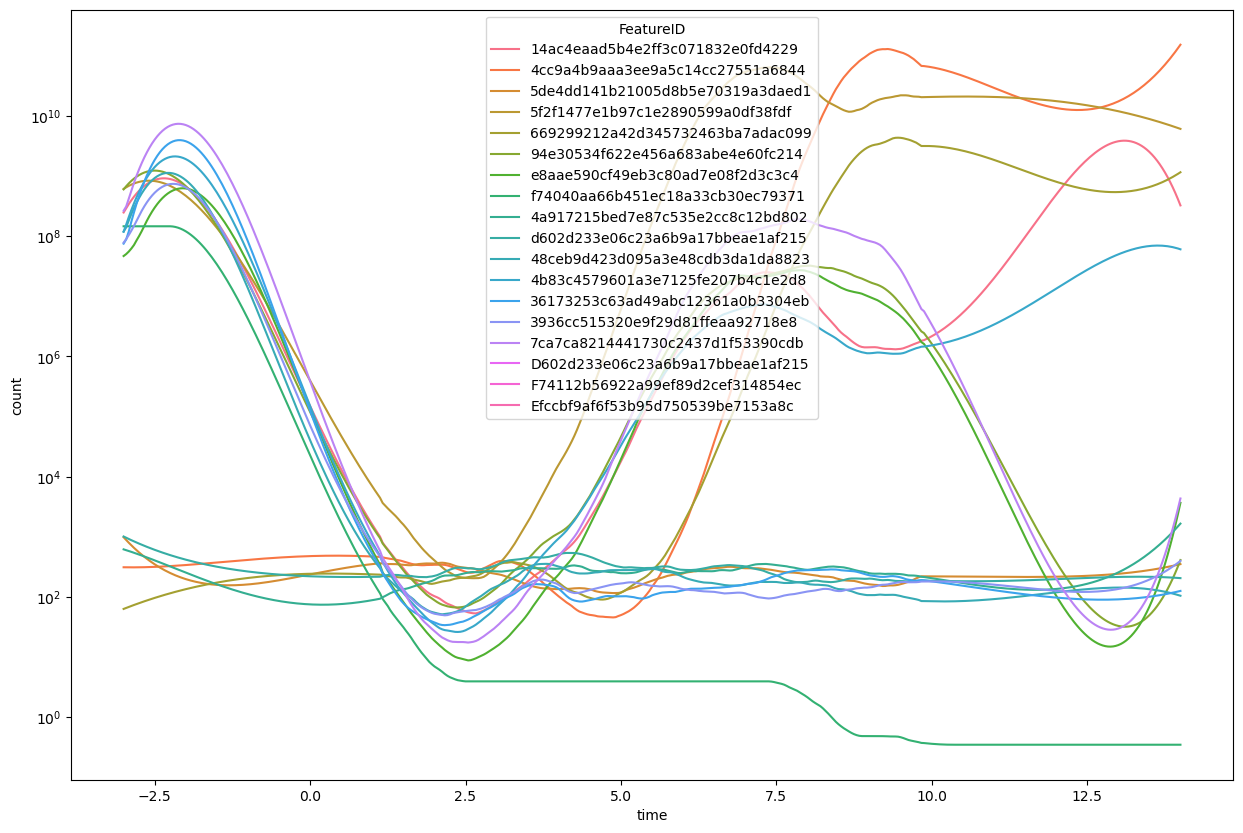

In [46]:
FBA_biomass = np.zeros([len(model_abun_dict.keys()), len(model_abun_dict['14ac4eaad5b4e2ff3c071832e0fd4229']['fba_biomass'])])
FBA_biomass

# %%
### Convert FBA abun output to relative abundance 
count = 0
for key in model_abun_dict:
    FBA_biomass[count,:] = model_abun_dict[key]['fba_biomass']
    count+=1

FBA_biomass_df = pd.DataFrame(FBA_biomass)
FBA_biomass_df.index = model_abun_dict.keys()

index_to_filter_by = FBA_biomass_df.index

## Tranform to relative abun

FBA_biomass_df = FBA_biomass_df/FBA_biomass_df.sum(axis=0)

### Need to just add the missing bug for now to the FBA output 
#FBA_biomass_df = FBA_biomass_df.T
#FBA_biomass_df['9cf5cb71450a2aa080ff905f89b0a624'] = 0
#FBA_biomass_df = FBA_biomass_df.T

FBA_biomass_df = FBA_biomass_df.melt(ignore_index=False)
FBA_biomass_df = FBA_biomass_df.reset_index()
FBA_biomass_df.columns = ['FeatureID','time', 'count']
FBA_biomass_df['time'] = ((FBA_biomass_df['time']/time_scaler))-3
FBA_biomass_df

# %%
FBA_biomass_df_plot = pd.DataFrame(FBA_biomass)
FBA_biomass_df_plot.index = model_abun_dict.keys()

FBA_biomass_df_plot = FBA_biomass_df_plot.melt(ignore_index=False)
FBA_biomass_df_plot = FBA_biomass_df_plot.reset_index()
FBA_biomass_df_plot.columns = ['FeatureID','time', 'count']
FBA_biomass_df_plot['time'] = (FBA_biomass_df_plot['time']/time_scaler)-3
FBA_biomass_df_plot['count'] = FBA_biomass_df_plot['count']*scal_fact

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=FBA_biomass_df_plot, x='time', y='count', hue = 'FeatureID')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abundances_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

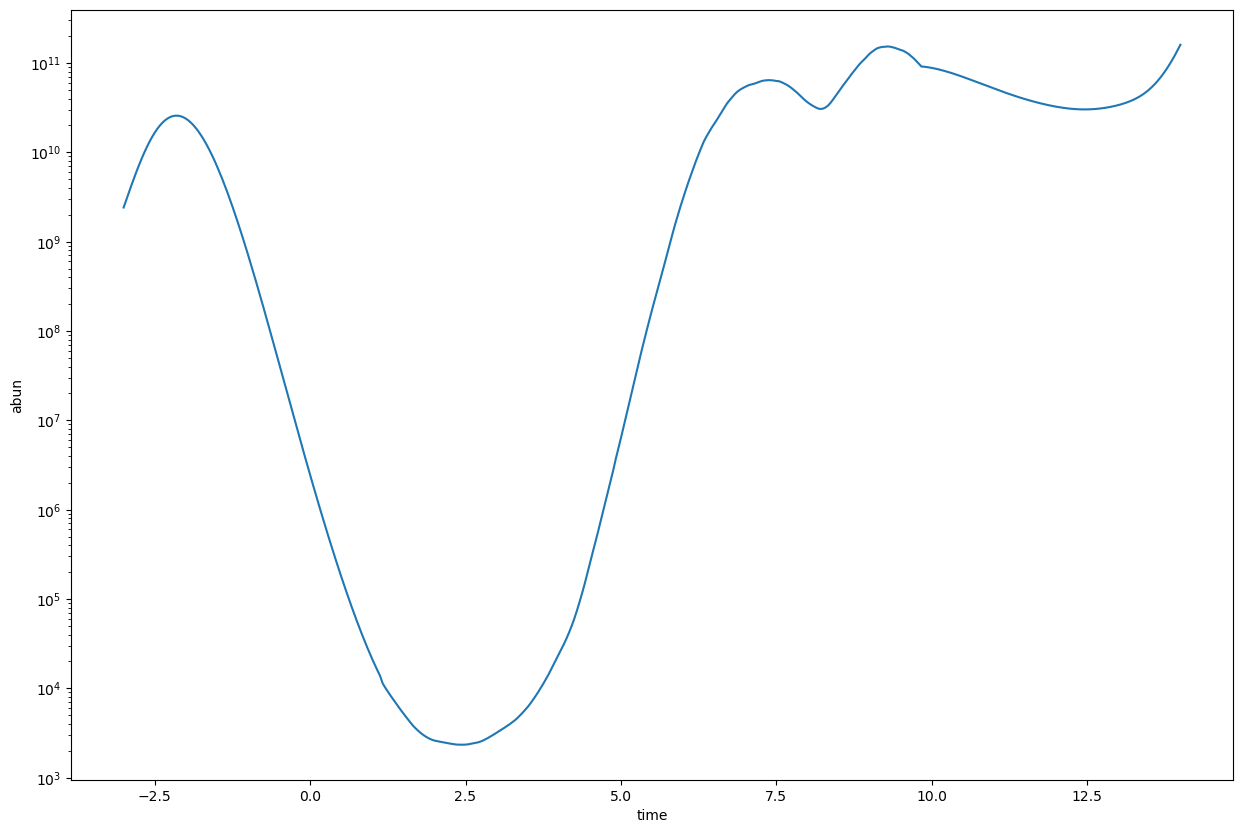

In [47]:
FBA_biomass_df_plot

FBA_biomass_df_plot_unstack = FBA_biomass_df_plot.pivot(index='FeatureID', columns ='time')['count']
FBA_biomass_df_plot_unstack = pd.DataFrame(FBA_biomass_df_plot_unstack.sum(axis=0)).reset_index()
FBA_biomass_df_plot_unstack.columns = ['time', 'abun']
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])

# %%
### Need to plot metabolite trajectories too

met_pool_over_time_df = pd.DataFrame(met_pool_over_time)
met_pool_over_time_df = met_pool_over_time_df.fillna(0)
met_pool_over_time_df_melt= met_pool_over_time_df.melt(ignore_index=False)
met_pool_over_time_df_melt = met_pool_over_time_df_melt.reset_index()
met_pool_over_time_df_melt.columns = ['Time','Metabolite', 'Concentration']
met_pool_over_time_df_melt

# %%
met_pool_over_time_df

# %%
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Concentration'] < 0]

# %%
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Metabolite'] == 'EX_adn(e)']

# %%
total_abun_MDSINE = pd.DataFrame(bi_hourly_resolution_latent_traj.sum(axis=0)).reset_index()
total_abun_MDSINE.columns = ['time', 'abun']
total_abun_MDSINE['time'] = pd.to_numeric(total_abun_MDSINE['time'])-3
total_abun_MDSINE.head()

# %%
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun')
plt.yscale('log')
plt.show()

# %%
output_folder = 'filtering_hourly_resolution'

    #plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num)


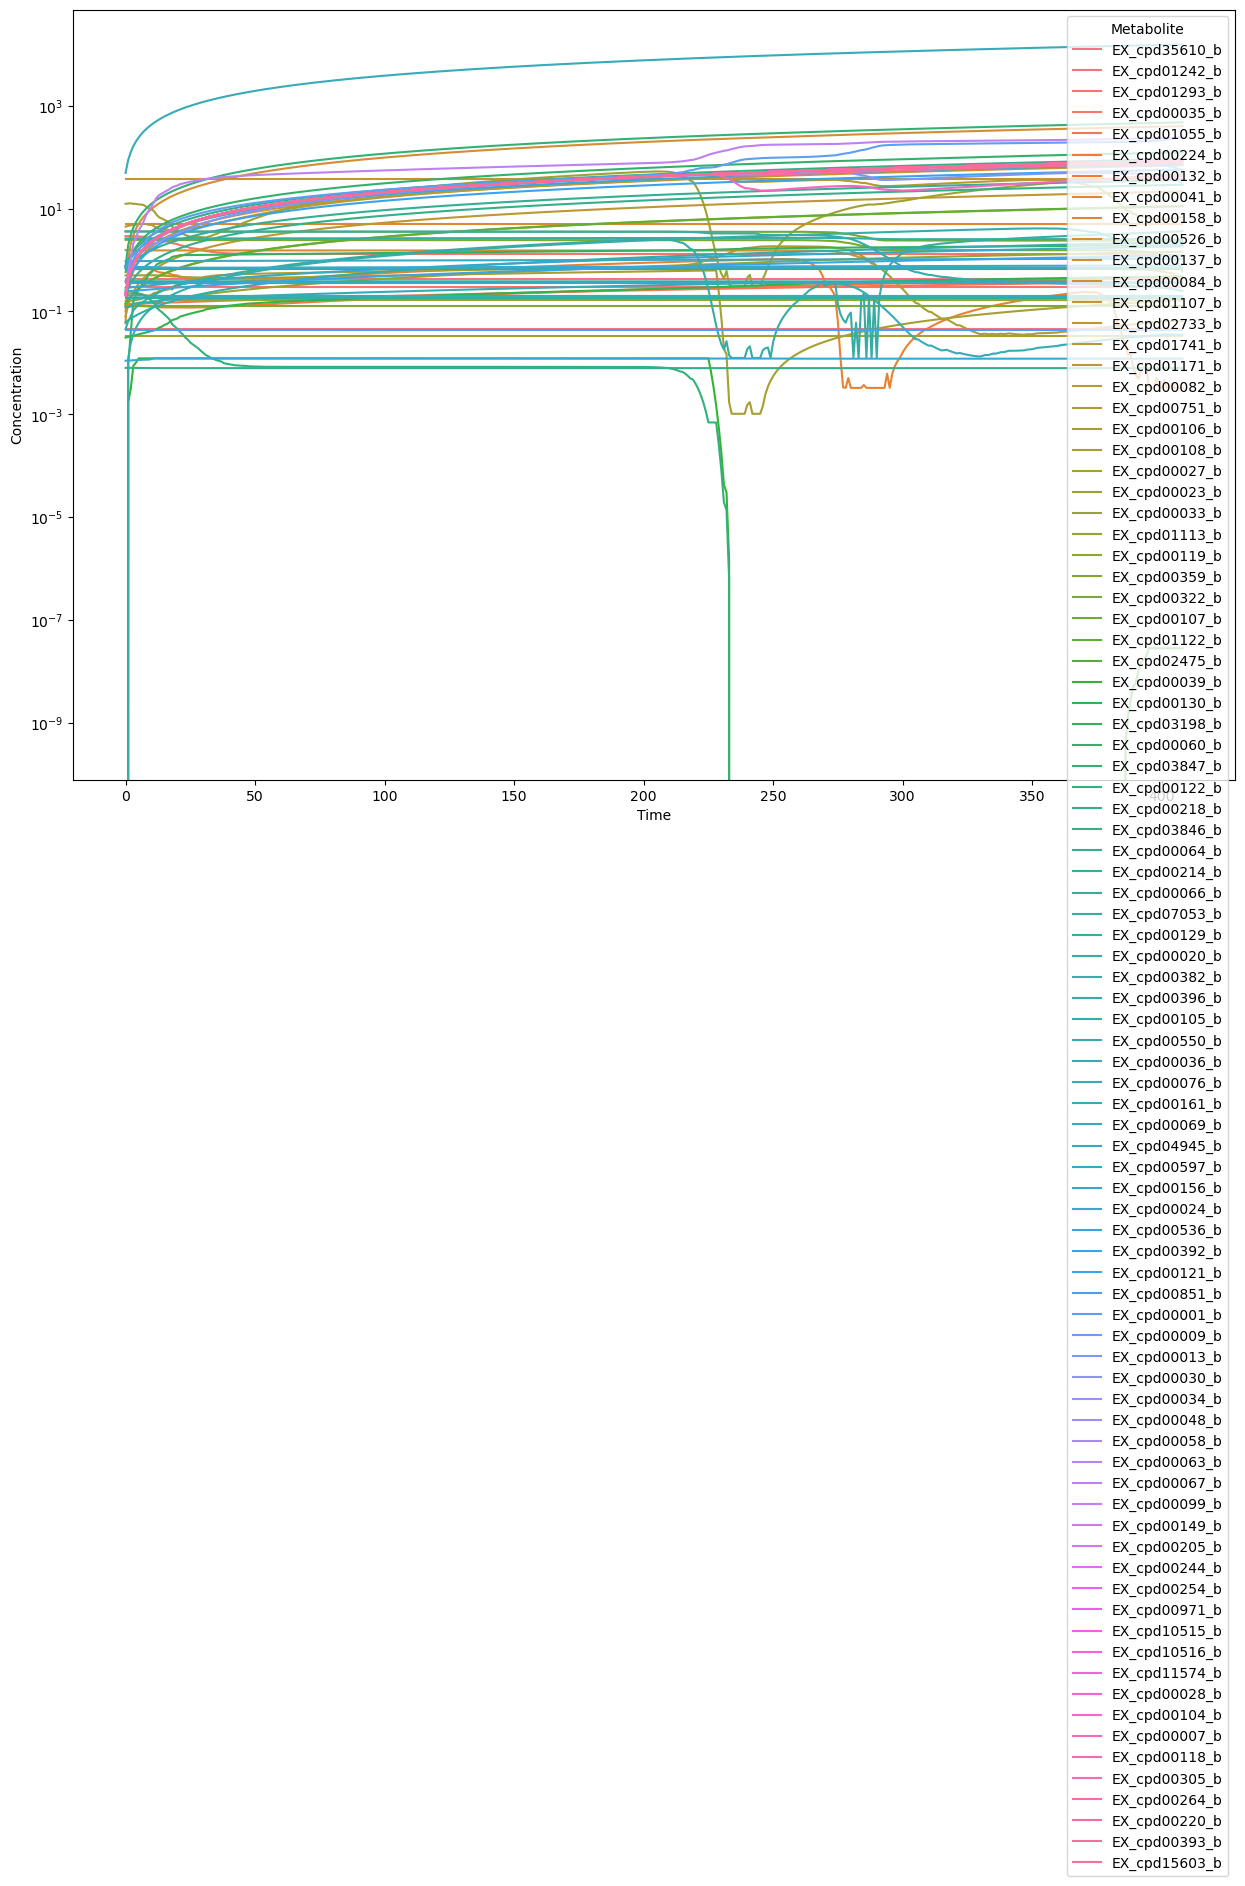

In [48]:
plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [49]:
ASV_string_to_species_names_dict = dict(zip(refseq_to_agora_df.index.tolist(), refseq_to_agora_df['Model_Names']))

                                  HF1162  HF1129  HF1189  HF1213  HF1261  \
FeatureID                                                                  
14ac4eaad5b4e2ff3c071832e0fd4229     216     627      47       0      14   
36173253c63ad49abc12361a0b3304eb     269     847     163      75       0   
3936cc515320e9f29d81ffeaa92718e8       8     636       0       0       0   
48ceb9d423d095a3e48cdb3da1da8823      65     435       0      27       0   
4a917215bed7e87c535e2cc8c12bd802       0       0       0       0       0   
4b83c4579601a3e7125fe207b4c1e2d8     144     750      79       0      20   
4cc9a4b9aaa3ee9a5c14cc27551a6844       0       0       0       0       0   
5de4dd141b21005d8b5e70319a3daed1       0       0       0       0       0   
5f2f1477e1b97c1e2890599a0df38fdf  160173     521   14677   35605   50803   
669299212a42d345732463ba7adac099       0       0       0       0       0   
7ca7ca8214441730c2437d1f53390cdb    1888    5803     959     538     354   
94e30534f622

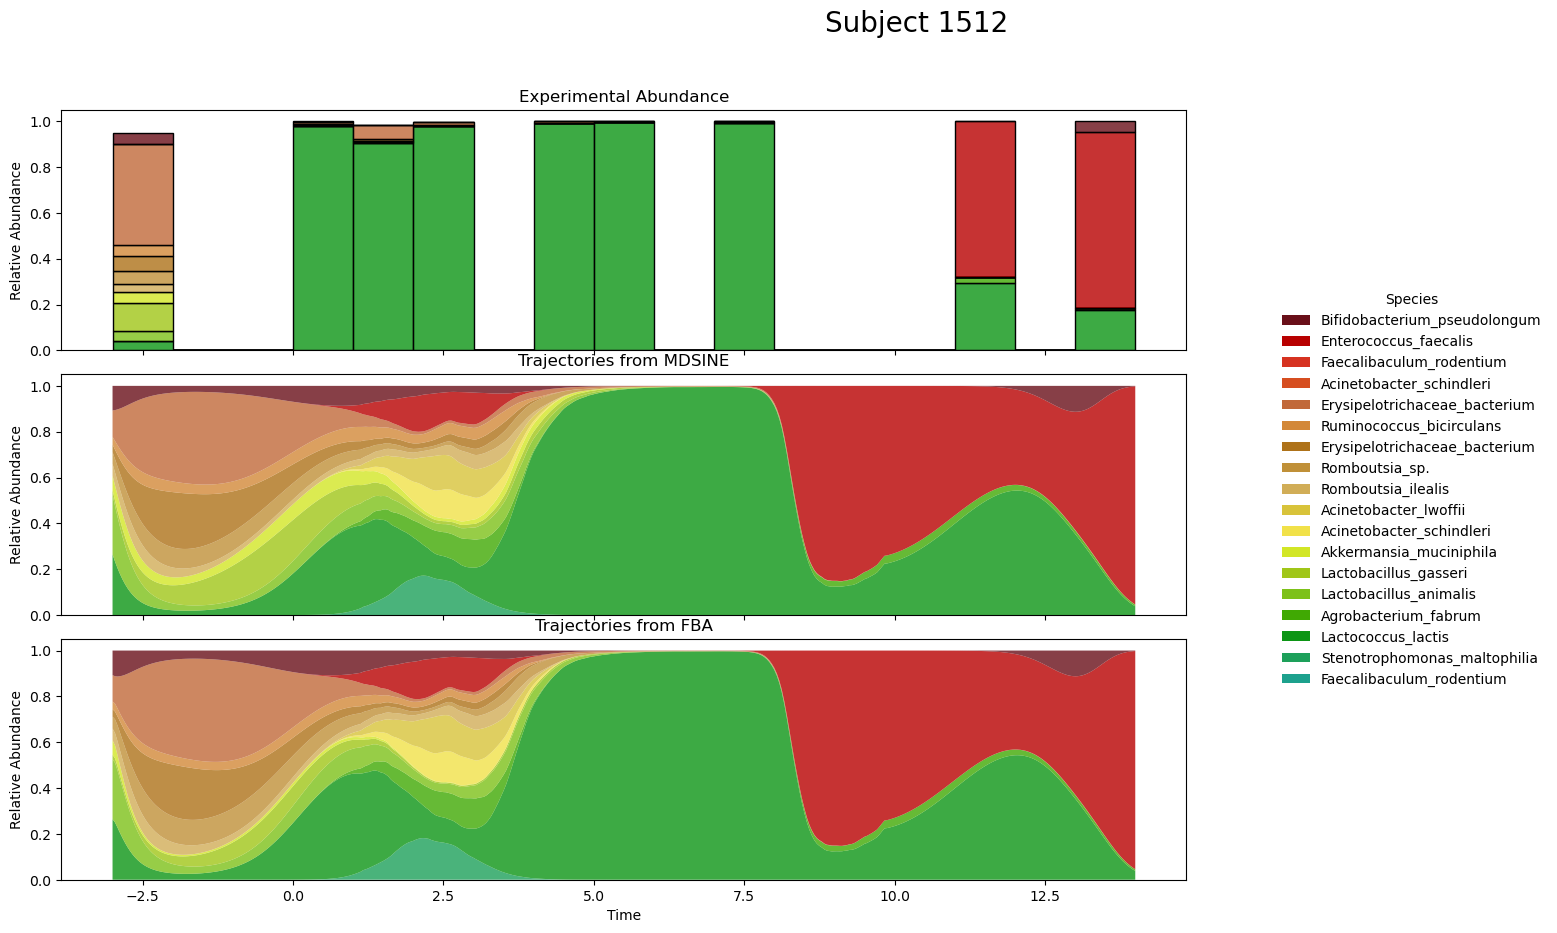

In [50]:
### Stacked plots 

## Directory to save plots to 


output_folder = 'WD_hourly_filtering'

#plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/MDSINE_vs_Exp_plots_' + output_folder + '/test_' + str(test_num)

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

samps_for_sub ={}


temp = metadata[metadata['subject'] == subject_to_plot]
testing = counts.filter(temp.index.tolist(), axis=1)
print(testing)
testing = testing.loc[~(testing==0).all(axis=1)]
qpcr_measurements = qpcr.reindex(testing.columns)
qpcr_measurements = qpcr_measurements['measurement1'].to_list()
testing_ra = testing.reindex(index_to_filter_by)
testing_ra = testing/testing.sum(axis=0)
testing_abs_abun = testing_ra*qpcr_measurements
time_dict = dict(zip(temp.index, temp['time'].tolist()))
testing_melt_ra = testing_ra.melt(ignore_index=False)
testing_melt_ra.columns = ['sample', 'count']
testing_melt_ra['time'] = testing_melt_ra['sample'].map(time_dict)
#print(testing_melt_ra.head())
testing_melt_abs_abun = testing_abs_abun.melt(ignore_index=False)
testing_melt_abs_abun.columns = ['sample', 'count']
testing_melt_abs_abun['time'] = testing_melt_abs_abun['sample'].map(time_dict)

# load in MDSINE output for each subject 
output_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_WD_abx_09_15_25/' + output_folder + '/Subject_' + str(subject_to_plot) + '/mean_smoothed.tsv'
MDSINE_output = pd.read_csv(output_path, delimiter='\t', index_col=0)


MDSINE_output = MDSINE_output.reindex(index_to_filter_by)

MDSINE_output = MDSINE_output/MDSINE_output.sum(axis=0)
MDSINE_output = MDSINE_output.melt(ignore_index=False)
MDSINE_output = MDSINE_output.reset_index()
MDSINE_output.columns = ['FeatureID','time', 'count']


###################
### Second plot ###
###################

fig, (ax_top, ax_middle, ax_bottom) = plt.subplots(
3, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
)

# Ensure time is numeric
MDSINE_output['time'] = pd.to_numeric(MDSINE_output['time'])-3
testing_melt_ra['time'] = pd.to_numeric(testing_melt_ra['time'])-3
FBA_biomass_df['time'] = pd.to_numeric(FBA_biomass_df['time'])

# Define stacking order
feature_order = MDSINE_output['FeatureID'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot

# Assign consistent colors


twentysiz = [
    "#690f19", "#b80000", "#d63220", "#d64e20", "#c1693a",  # reds/oranges
    "#d38838", "#AE7219", "#C09038", "#d1ad57", "#d8c33a", "#f1e149",  # orange/yellows
    "#d2e626", "#a0c618", "#7dc119", "#40a903", "#0c9515",  # yellow/green
    "#1da05a", "#1da18d", "#1d91a1", "#1d6ea1", "#1d31a1",  # green/blue
    "#1a1a87", "#5b5bc9", "#8d8df1", "#8670cc", "#9870cc",  # blue/purple
    "#000000"  # black
]
#sns.set_style("dark")  # or "whitegrid", "dark", etc.
#sns.set_context("notebook")  # or "paper", "talk", "poster"
sns.set_palette(twentysiz)

#palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, twentysiz))

# Pivot for stackplot in reversed stacking order
continuous_pivot_MDSINE = (
    MDSINE_output
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]

# Pivot for stackplot in reversed stacking order
continuous_pivot_FBA = (
    FBA_biomass_df
    .pivot(index='time', columns='FeatureID', values='count')
    .fillna(0)
)[reversed_order]



# Set categorical order for histogram
testing_melt_ra['FeatureID'] = pd.Categorical(testing_melt_ra.reset_index()['FeatureID'], categories=feature_order, ordered=True)

# Top: histogram
sns.histplot(
    data=testing_melt_ra,
    x='time',
    weights='count',
    hue='FeatureID',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)
ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Middle: stackplot using reversed order and matching colors
ax_middle.stackplot(
    continuous_pivot_MDSINE.index,
    *[continuous_pivot_MDSINE[col] for col in continuous_pivot_MDSINE.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_middle.set_ylabel('Relative Abundance')
#ax_middle.set_xlabel('Time')
ax_middle.set_title('Trajectories from MDSINE')

# Bottom: stackplot using FBA output 

# Bottom: stackplot using reversed order and matching colors
ax_bottom.stackplot(
    continuous_pivot_FBA.index,
    *[continuous_pivot_FBA[col] for col in continuous_pivot_FBA.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)
ax_bottom.set_ylabel('Relative Abundance')
ax_bottom.set_xlabel('Time')
ax_bottom.set_title('Trajectories from FBA')



# Tidy layout
ax_top.tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1, right=0.75)


# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=ASV_string_to_species_names_dict[feat])
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Species',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
second_plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_stacked_hist_line_plots_FBA_' + str(test_num) + '.pdf'
plt.savefig(second_plot_file_name, bbox_inches="tight")
plt.show()




In [51]:
testing_melt_abs_abun = testing_melt_abs_abun.reset_index()
testing_melt_abs_abun.columns = ['FeatureID', 'sample', 'count', 'time']

In [52]:
testing_melt_abs_abun_unstack = testing_melt_abs_abun.reset_index().pivot(index='FeatureID', columns ='time')['count']
testing_melt_abs_abun_unstack = pd.DataFrame(testing_melt_abs_abun_unstack.sum(axis=0)).reset_index()
testing_melt_abs_abun_unstack.columns = ['time', 'abun']
testing_melt_abs_abun_unstack['time'] = pd.to_numeric(testing_melt_abs_abun_unstack['time'])-3.0
testing_melt_abs_abun_unstack

,time,abun
0,-3.0,6.903209e+09
1,0.0,1.000000e+03
2,1.0,1.000000e+03
3,2.0,1.000000e+03
4,4.0,1.000000e+03
5,5.0,1.000000e+03
6,7.0,1.346025e+10
7,11.0,4.497340e+10
8,14.0,4.405097e+10


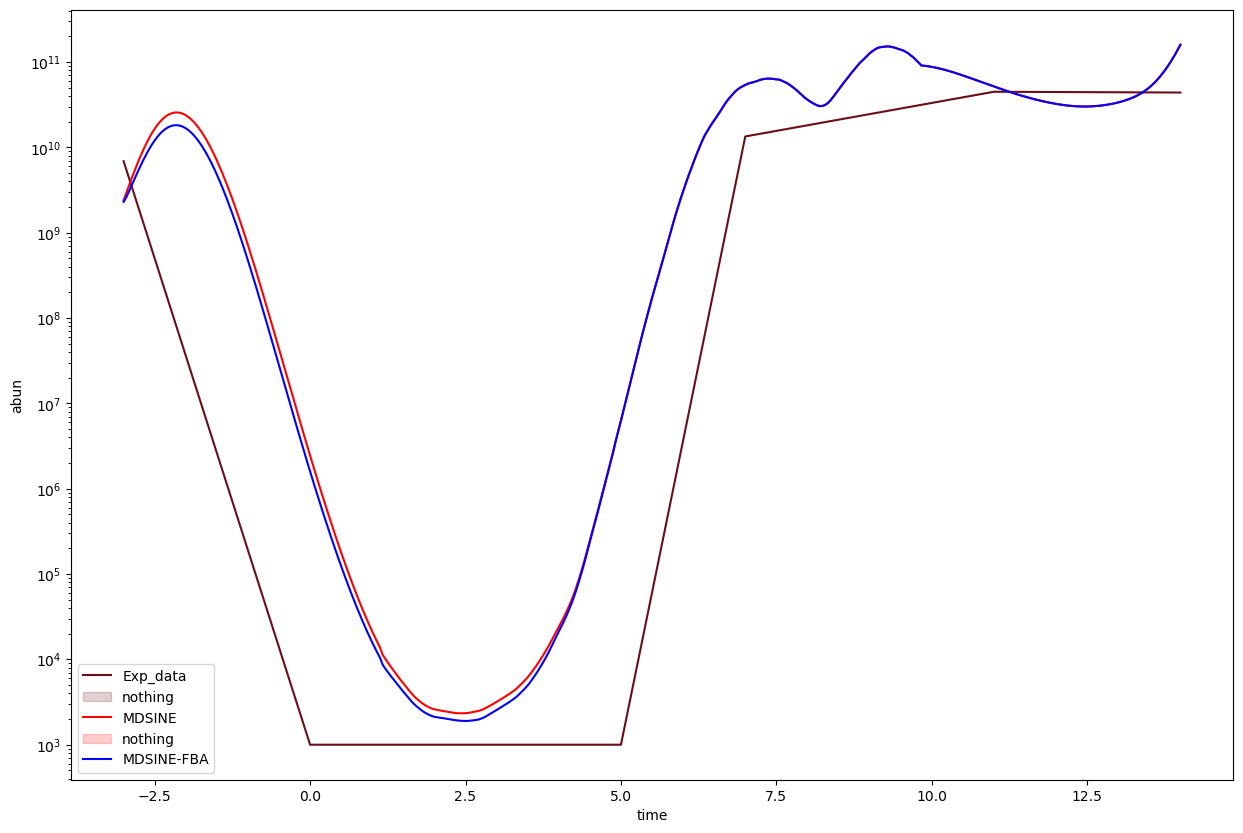

In [53]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=testing_melt_abs_abun_unstack, x='time', y='abun')
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun', color = 'red')
sns.lineplot(data=FBA_biomass_df_plot_unstack, x='time', y='abun', color = 'blue')
plt.legend(['Exp_data', 'nothing', 'MDSINE', 'nothing', 'MDSINE-FBA'])
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_comparison_abs_abun_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [54]:
### Here plot the metabolomics data 
metabolomics_metadata_sub = metabolomics_metadata_raw[metabolomics_metadata_raw['Mouse'] == float(subject_to_predict)]
metabolomics_metadata_sub

met_days_dict = dict(zip(metabolomics_metadata_sub.index.tolist(),metabolomics_metadata_sub['Rec_day_adj'].tolist() ))
met_days_dict

{'HF2848': 14, 'HF1128': -3, 'HF1307': 7, 'HF1357': 11}

In [55]:
metabolomics_data

,SampleName,12_Ketolithocholic acid,drib,5oxpro,ala__L,all__D,arab__L,asn__L,asp__L,cellb,...,thr__L,tyr__L,HC02194,pta,val__L,akg,cis_Oleic acid,meso_Erythritol,inost,4hpro_LT
0,HF1114,0.135,0.272,0.199,6.991,0.049,12.191,0.000,0.178,0.000,...,0.248,0.791,0.000,3.766,0.493,0.043,7.512,0.084,2.029,0.581
1,HF1115,0.263,0.285,0.305,11.053,0.069,15.784,0.000,0.243,0.520,...,0.423,6.104,0.064,1.350,1.086,0.056,8.391,0.139,1.919,1.908
2,HF1119,0.212,0.059,0.132,2.192,0.042,0.139,0.000,0.073,0.409,...,0.132,0.587,0.037,0.110,0.454,0.000,8.760,0.038,0.195,0.020
3,HF1120,0.528,0.067,0.122,1.459,0.030,0.175,0.000,0.062,0.000,...,0.105,0.520,0.307,0.400,0.431,0.023,14.081,0.049,0.099,0.027
4,HF1124,0.147,0.381,0.637,15.682,0.035,9.139,0.000,0.258,0.000,...,0.529,0.912,0.013,6.306,0.881,0.471,1.399,0.088,0.637,0.332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,HF560,0.000,0.030,0.437,0.854,0.480,0.965,0.068,0.404,3.431,...,0.851,0.790,0.000,0.042,0.592,0.000,0.970,0.044,1.723,0.022
65,HF562,0.172,0.147,0.273,3.863,0.000,4.088,0.000,1.004,0.507,...,0.288,1.198,0.108,1.423,0.391,0.011,4.890,0.055,0.906,0.125
66,HF569,0.000,0.040,0.945,0.936,0.373,0.627,0.102,1.530,3.313,...,1.565,2.378,0.000,0.047,1.090,0.000,1.989,0.052,4.915,0.046
67,HF571,0.075,0.091,0.201,3.675,0.034,5.773,0.000,0.386,0.347,...,0.237,1.194,0.073,1.312,0.428,0.009,5.692,0.000,0.823,0.267


In [56]:

intersection_mets_timepoints = set(list(met_days_dict.keys())).intersection(set(metabolomics_data['SampleName'].to_list()))

In [57]:
filtered_dict = {key: met_days_dict[key] for key in intersection_mets_timepoints if key in met_days_dict}
filtered_dict

{'HF2848': 14, 'HF1307': 7, 'HF1357': 11, 'HF1128': -3}

In [58]:
### Filter the metabolomics data by the correct samples

metabolomics_data_sub = metabolomics_data[metabolomics_data['SampleName'].isin(met_days_dict.keys())]
metabolomics_data_sub = metabolomics_data_sub.set_index('SampleName')
metabolomics_data_sub_ra = metabolomics_data_sub.T/metabolomics_data_sub.T.sum(axis=0)
metabolomics_data_sub_ra.columns = np.sort(list(filtered_dict.values()))

#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948_ra.index.tolist())
change_met_ids = []
for i in metabolomics_data_sub_ra.index.tolist():
    change_met_ids.append('EX_' + bigg_to_modelseed[i] + '_b')
metabolomics_data_sub_ra.index = change_met_ids
#metabolomics_data_sub_1948_ra.head()

change_met_ids = metabolomics_data_sub_ra.index.tolist()


In [59]:
met_pool_over_time_df_melt_filt = met_pool_over_time_df_melt.set_index('Metabolite').loc[change_met_ids].reset_index()
met_pool_over_time_df_melt_filt.head()

,Metabolite,Time,Concentration
0,EX_cpd35610_b,0,0.434
1,EX_cpd35610_b,1,0.434
2,EX_cpd35610_b,2,0.434
3,EX_cpd35610_b,3,0.434
4,EX_cpd35610_b,4,0.434


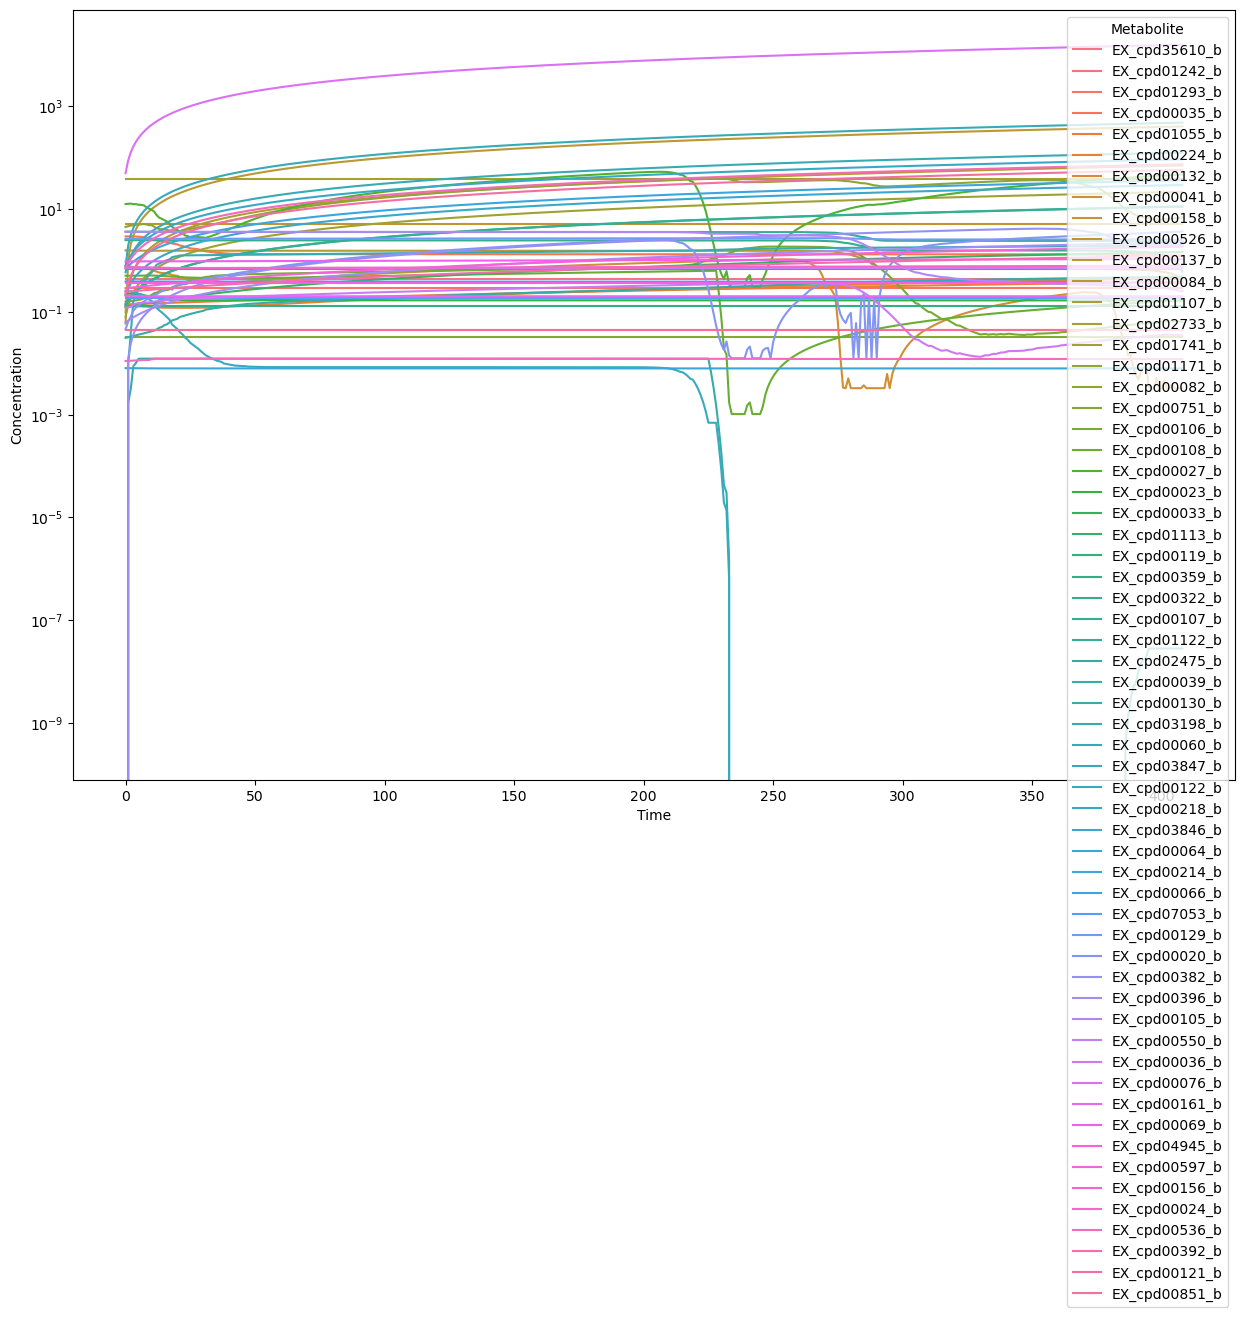

In [60]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt_filt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_filt' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()


In [61]:
metabolomics_data_sub_ra_melt = metabolomics_data_sub_ra.melt(ignore_index=False).reset_index()
metabolomics_data_sub_ra_melt.columns = ['metabolites', 'time', 'concentration']
metabolomics_data_sub_ra_melt.head()

,metabolites,time,concentration
0,EX_cpd35610_b,-3,0.003120
1,EX_cpd01242_b,-3,0.000323
2,EX_cpd01293_b,-3,0.002121
3,EX_cpd00035_b,-3,0.021083
4,EX_cpd01055_b,-3,0.000999


In [62]:
cmpd_names_adjust = []
for i in cmpd_names:
    cmpd_names_adjust.append('EX_' + i + '_b')

In [63]:
met_pool_over_time_df_filt = met_pool_over_time_df.T.loc[cmpd_names_adjust]
met_pool_over_time_df_filt = met_pool_over_time_df_filt.T.reset_index()
met_pool_over_time_df_filt['index'] = (met_pool_over_time_df_filt['index']/time_scaler)-3
met_pool_over_time_df_filt = met_pool_over_time_df_filt.set_index('index').T
met_pool_over_time_df_filt_ra = met_pool_over_time_df_filt/met_pool_over_time_df_filt.sum(axis=0)
met_pool_over_time_df_filt_ra_melt = met_pool_over_time_df_filt_ra.melt(ignore_index=False).reset_index()
met_pool_over_time_df_filt_ra_melt.columns = ['metabolites', 'time', 'concentration']
met_pool_over_time_df_filt_ra_melt.head()

,metabolites,time,concentration
0,EX_cpd35610_b,-3.0,0.003120
1,EX_cpd01242_b,-3.0,0.000323
2,EX_cpd01293_b,-3.0,0.002121
3,EX_cpd00035_b,-3.0,0.021083
4,EX_cpd01055_b,-3.0,0.000999


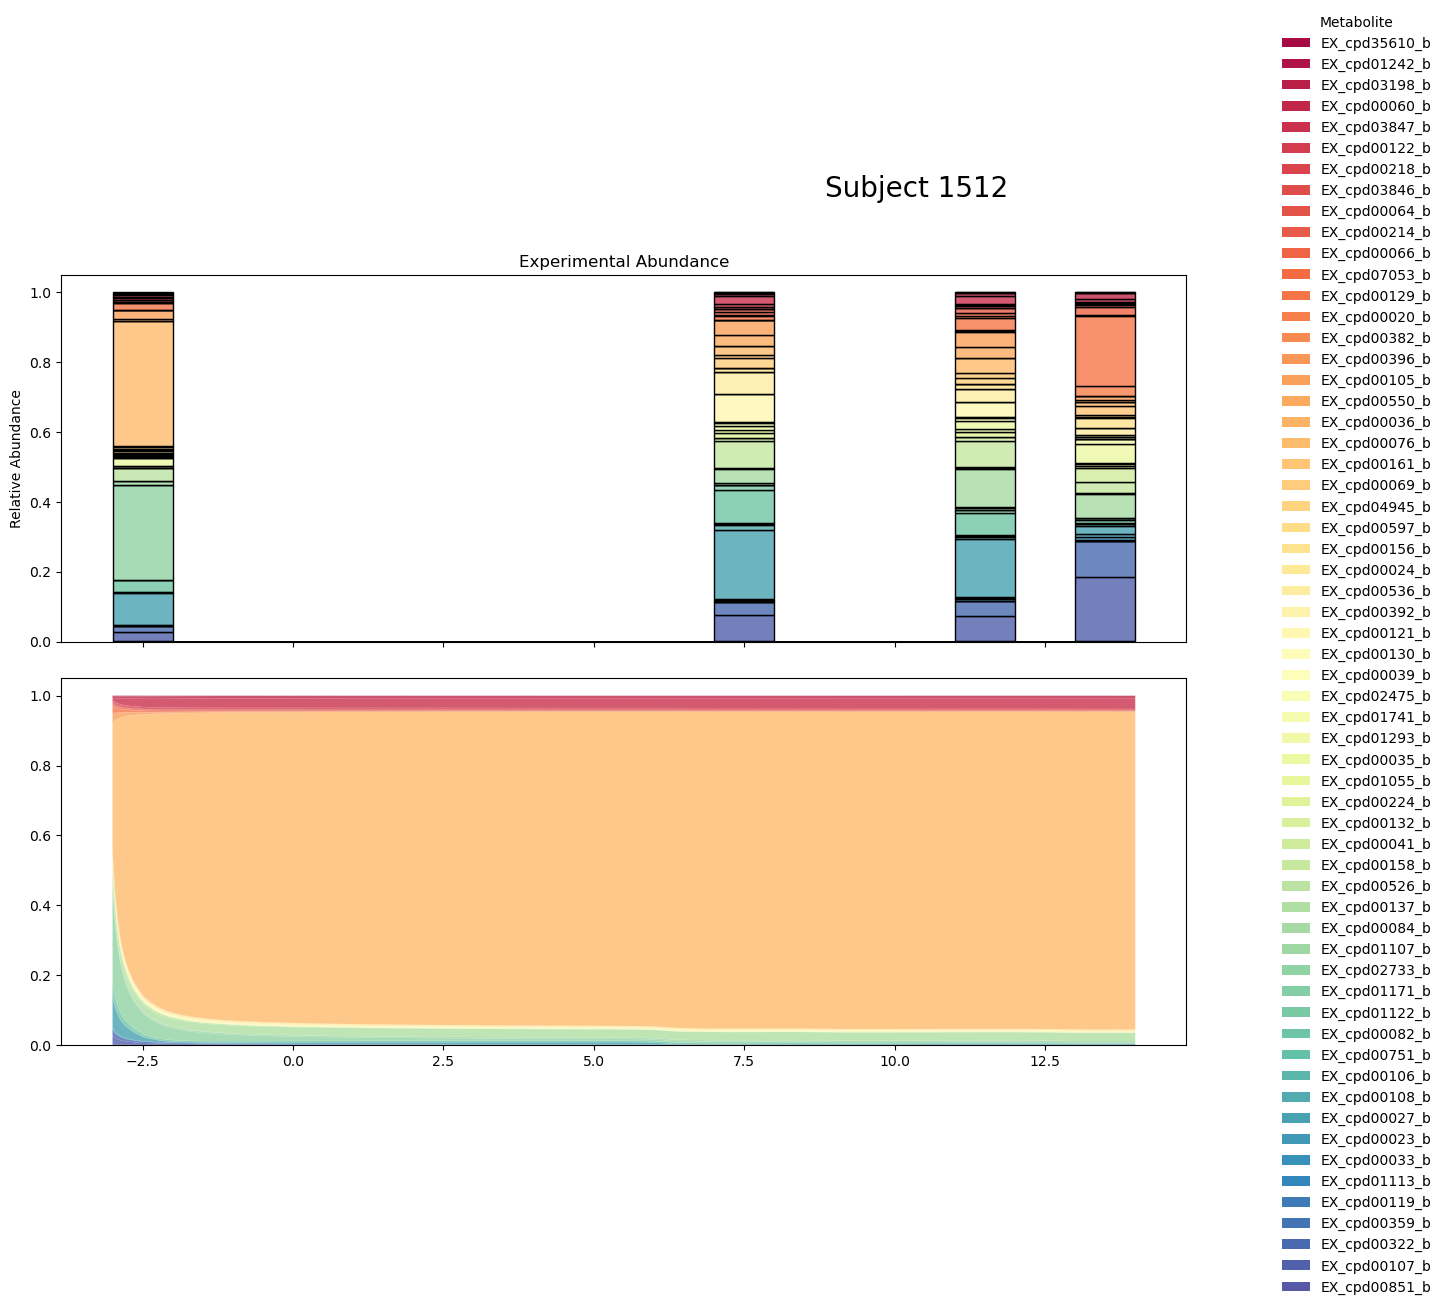

In [64]:
fig, (ax_top, ax_bottom) = plt.subplots(
2, 1, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]}
)

# Define stacking order
feature_order = metabolomics_data_sub_ra_melt['metabolites'].value_counts().index.tolist()
reversed_order = feature_order[::-1]  # For stackplot



palette = sns.color_palette("Spectral", n_colors=len(feature_order))  # or use 'husl', 'Set2', etc.
color_map = dict(zip(feature_order, palette))

# Pivot for stackplot in reversed stacking order
met_pool_over_time_df_filt_ra_pivot = (
    met_pool_over_time_df_filt_ra_melt
    .pivot(index='time', columns='metabolites', values='concentration')
    .fillna(0)
)[reversed_order]

# Set categorical order for histogram
metabolomics_data_sub_ra_melt['metabolites'] = pd.Categorical(metabolomics_data_sub_ra_melt.reset_index()['metabolites'], categories=feature_order, ordered=True)

# Top: histogram
sns.histplot(
    data=metabolomics_data_sub_ra_melt,
    x='time',
    weights='concentration',
    hue='metabolites',
    multiple='stack',
    ax=ax_top,
    alpha=0.8,
    binwidth=1,
    palette=color_map
)
ax_top.legend_.remove()
ax_top.set_ylabel('Relative Abundance')
ax_top.set_title('Experimental Abundance')
#ax_top.legend(title='FeatureID', bbox_to_anchor=(1.05, 1), loc='upper left')

ax_bottom.stackplot(
    met_pool_over_time_df_filt_ra_pivot.index,
    *[met_pool_over_time_df_filt_ra_pivot[col] for col in met_pool_over_time_df_filt_ra_pivot.columns],
    alpha=0.8,
    colors=[color_map[feat] for feat in reversed_order],
    labels=reversed_order
)

# Create custom legend handles using your color map
legend_elements = [
    Patch(facecolor=color_map[feat], label=feat)
    for feat in feature_order
]

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=0.1, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_over_time_test_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [65]:
metabolomics_data_sub = metabolomics_data_sub.T

metabolomics_data_sub.columns = np.sort(list(filtered_dict.values()))
metabolomics_data_sub


,-3,7,11,14
12_Ketolithocholic acid,0.434,0.000,0.000,0.000
drib,0.045,0.041,0.021,0.039
5oxpro,0.295,0.712,0.475,1.175
ala__L,2.933,1.039,1.038,5.090
all__D,0.139,0.823,0.324,0.170
arab__L,0.126,1.389,0.617,0.648
asn__L,0.000,0.075,0.031,0.456
asp__L,0.757,0.729,0.485,3.777
cellb,0.000,7.049,3.430,2.823
cholate,5.003,0.123,0.161,0.095


In [66]:
#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948.index.tolist())
metabolomics_data_sub.index = change_met_ids
metabolomics_data_sub.head()

,-3,7,11,14
EX_cpd35610_b,0.434,0.000,0.000,0.000
EX_cpd01242_b,0.045,0.041,0.021,0.039
EX_cpd01293_b,0.295,0.712,0.475,1.175
EX_cpd00035_b,2.933,1.039,1.038,5.090
EX_cpd01055_b,0.139,0.823,0.324,0.170


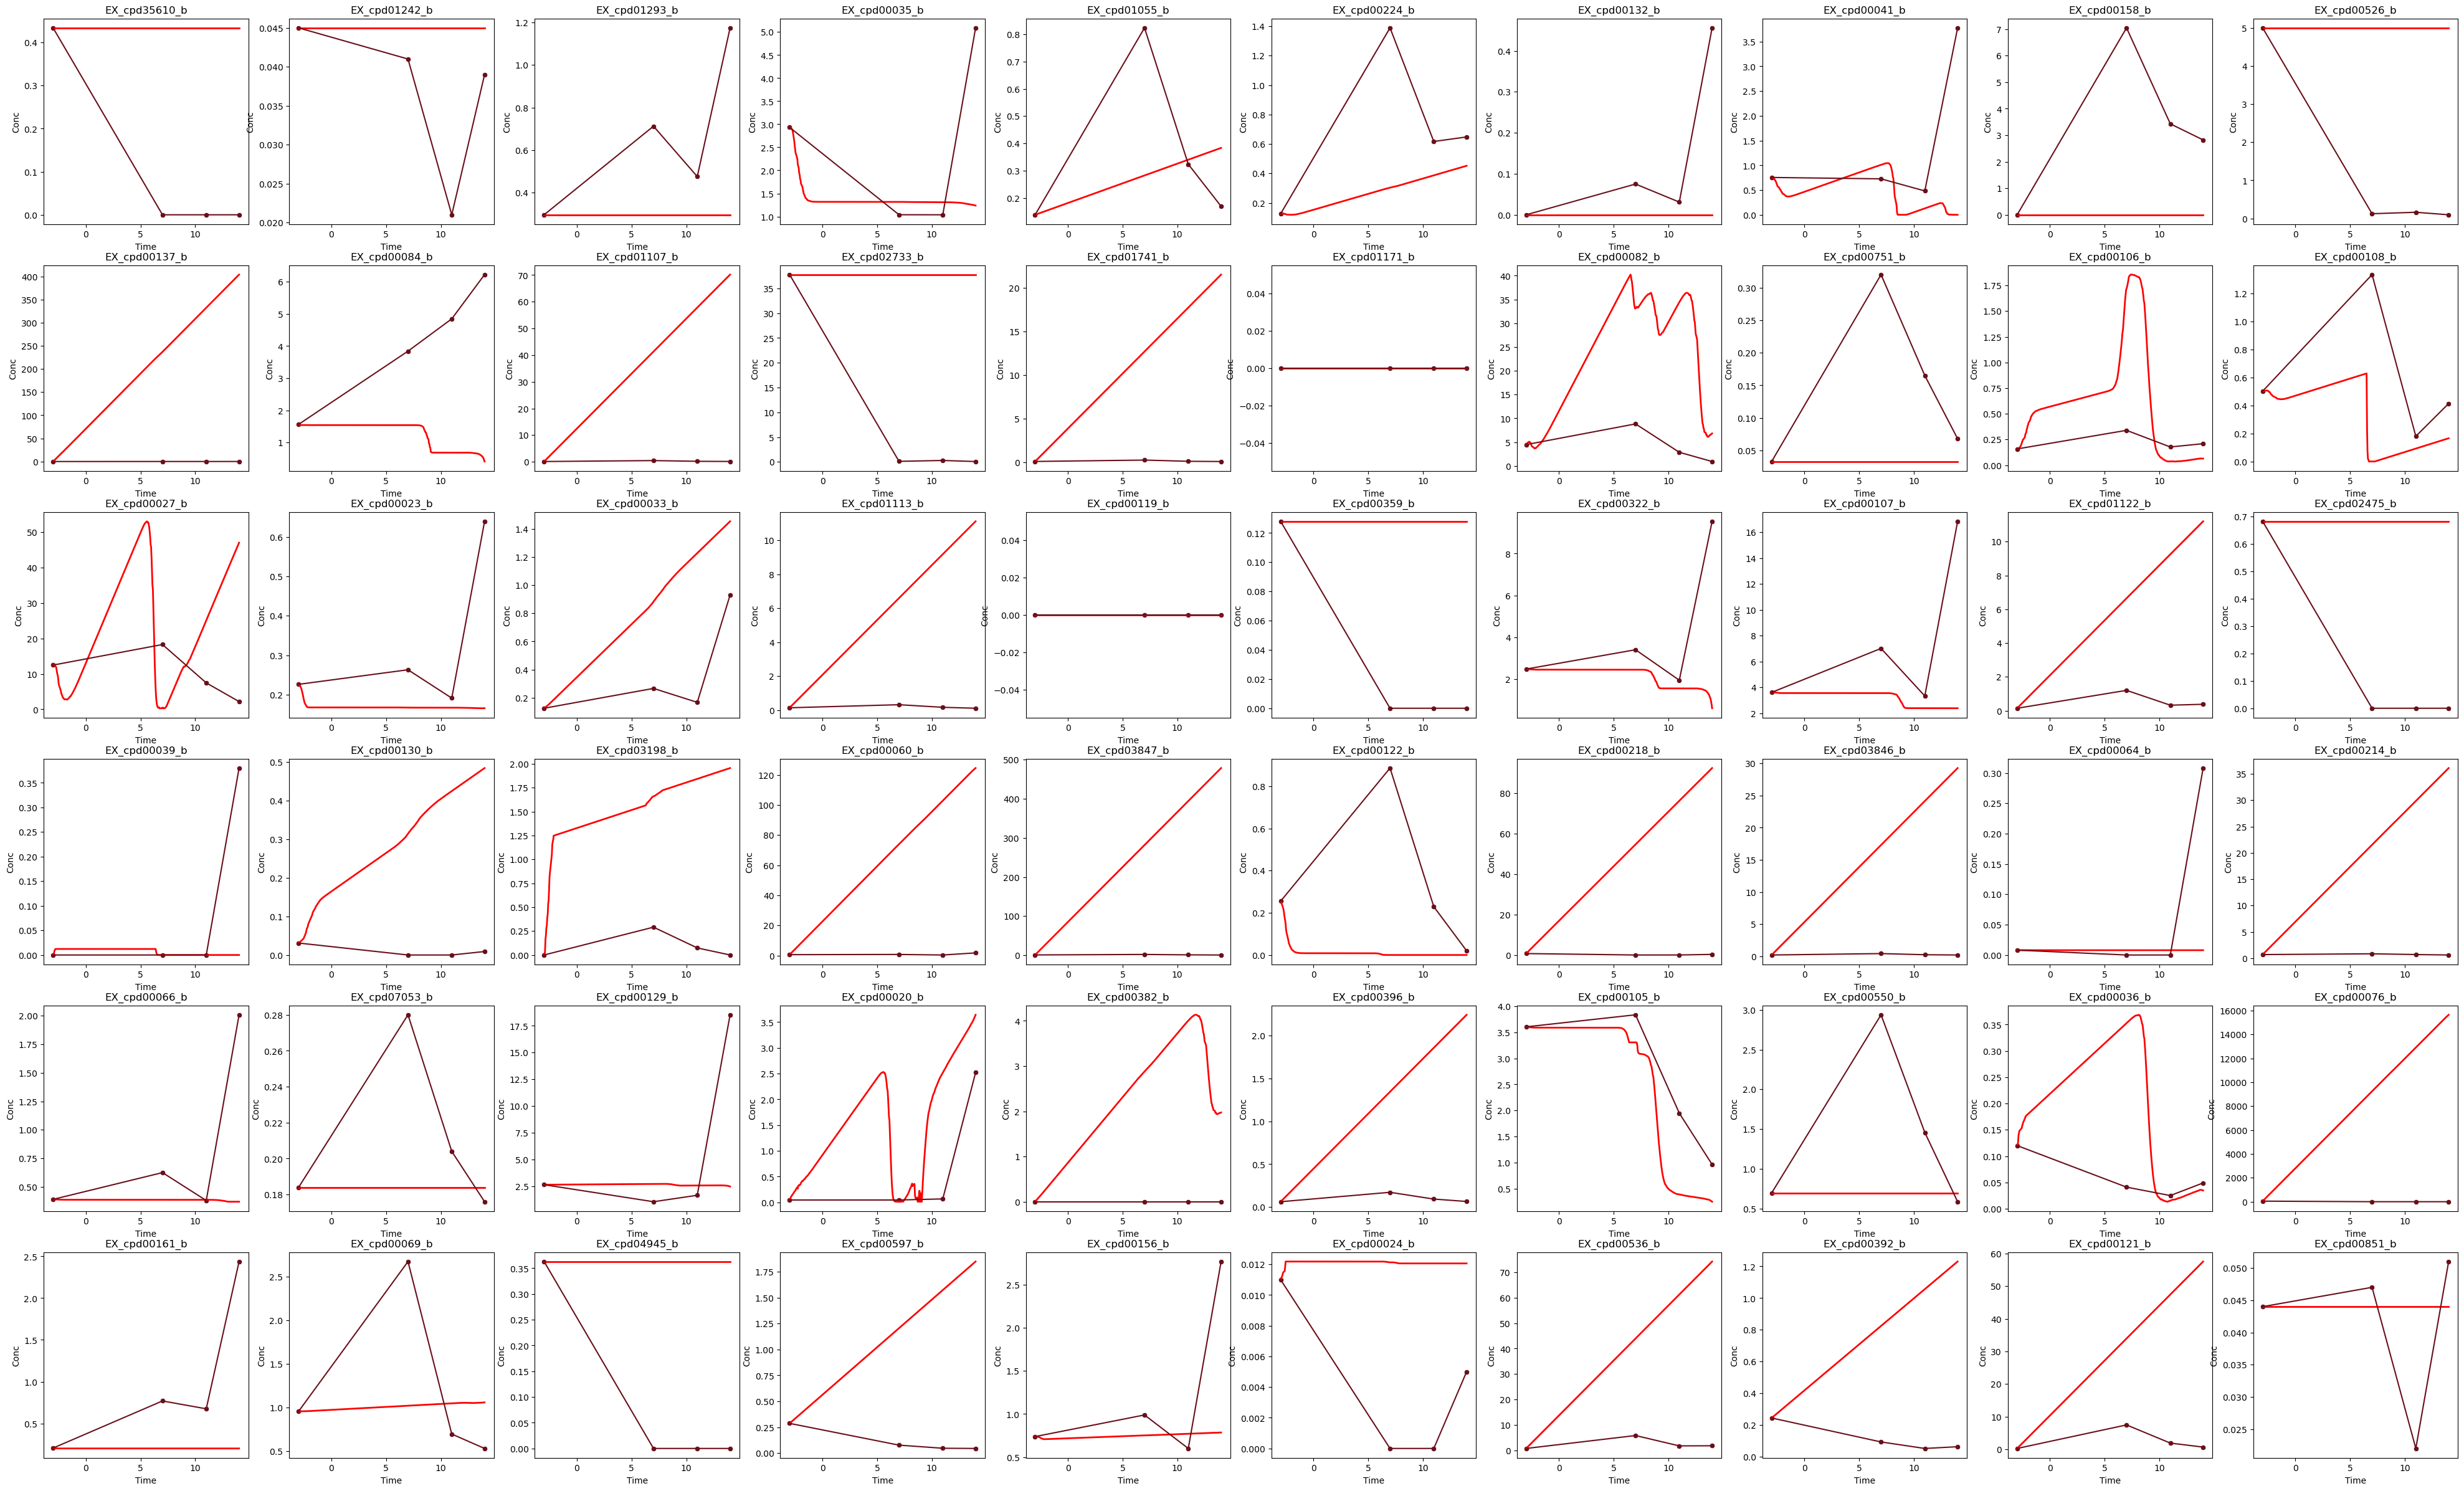

In [67]:

num_plots = 60
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)
total_rmse = 0
# Flatten the axes array for easy iteration
axes = axes.flatten()
corr_dict = {}
rmse_dict = {}
for i,met in enumerate(met_pool_over_time_df_filt.index.tolist()):
    temp_sim = met_pool_over_time_df_filt.loc[met,:]
    temp_exp = metabolomics_data_sub.loc[met,:]
    #temp_int = interpolated_met_values.loc[met,:]

    #temp_pearson = pearsonr(temp_sim.to_list(), temp_int.to_list()[:415])

    #true = np.array(temp_int.to_list()[:415])
    pred = np.array(temp_sim.to_list())

    #rmse = np.sqrt(np.mean((true - pred)**2))
    #norm = true.max() - true.min()
    #nrmse = rmse/norm
    #if np.isnan(nrmse):
    #    nrmse = 0
    #rmse_dict[met] = nrmse
    #total_rmse += nrmse

    #temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    #temp_pearson_p_val_round = np.round(temp_pearson.pvalue,4)
    #corr_dict[met] = temp_pearson_stat_round
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'red', lw = 2)
    #sns.lineplot(ax = axes[i], x = temp_sim.index.to_list(), y = list(savgol_filter(temp_sim.to_list(),300,3)), color = 'blue', lw = 2)
    sns.scatterplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    sns.lineplot(ax=axes[i], x=temp_exp.index.to_list(), y=temp_exp.to_list())
    #sns.lineplot(ax=axes[i], x=temp_int.index.to_list(), y=temp_int.to_list(), color = 'green')

    #axes[i].set_title(f"{met}\n Pearson: {temp_pearson_stat_round}\n Pearson p val: {temp_pearson_p_val_round}")
    axes[i].set_title(f"{met}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
if mets_used_for_constraint == 0:
    subtract = 0
else:
    subtract = len(mets_used_for_constraint)
#plt.subplots_adjust(hspace=.5)
rmse_dict['total_rmse'] = total_rmse/(60-subtract)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")

In [68]:
metabolomics_data_sub_melt = metabolomics_data_sub.melt(ignore_index=False).reset_index()
metabolomics_data_sub_melt.columns = ['metabolites', 'time', 'concentration']
metabolomics_data_sub_melt.head()

,metabolites,time,concentration
0,EX_cpd35610_b,-3,0.434
1,EX_cpd01242_b,-3,0.045
2,EX_cpd01293_b,-3,0.295
3,EX_cpd00035_b,-3,2.933
4,EX_cpd01055_b,-3,0.139


In [69]:
### Prepare the simulation metabolomic data 
met_pool_over_time_df_filt_melt = met_pool_over_time_df_filt.melt(ignore_index=False).reset_index()
met_pool_over_time_df_filt_melt.columns = ['metabolites', 'time', 'concentration']
met_pool_over_time_df_filt_melt.head()
# use this to filter, agora_ex_ids_list

,metabolites,time,concentration
0,EX_cpd35610_b,-3.0,0.434
1,EX_cpd01242_b,-3.0,0.045
2,EX_cpd01293_b,-3.0,0.295
3,EX_cpd00035_b,-3.0,2.933
4,EX_cpd01055_b,-3.0,0.139


In [70]:
final_rounded_time_pt = met_pool_over_time_df_filt_melt['time'].max().round()

In [71]:
met_pool_over_time_df_filt_melt.loc[
    met_pool_over_time_df_filt_melt['time'] == met_pool_over_time_df_filt_melt['time'].max(), 
    'time'
] = 14


In [72]:
### ok now make scatterplot for each time point 

metabolomics_data_sub_melt['time'] = pd.to_numeric(metabolomics_data_sub_melt['time'], downcast='float') 
merged_exp_sim_met_data = metabolomics_data_sub_melt.merge(met_pool_over_time_df_filt_melt, on=['time', 'metabolites'])
merged_exp_sim_met_data.columns = ['metabolites', 'time', 'exp_conc', 'sim_conc']
#met_pool_over_time_df_filt_ra

In [73]:
x = y = np.linspace(0,25,50)

1.0
0.3892434035433319
0.38857416923678845
0.21977052465173835


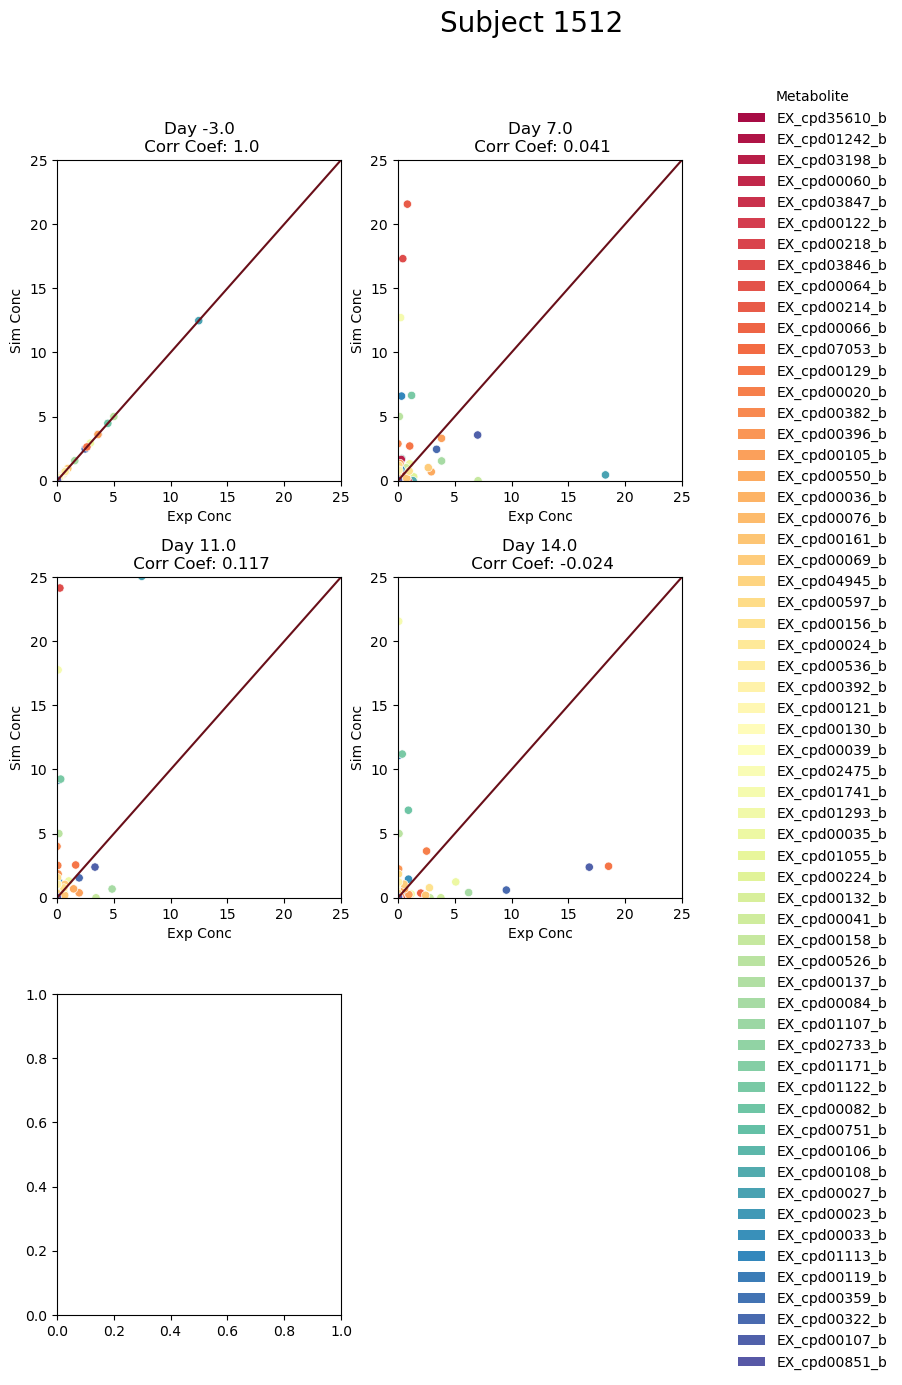

In [74]:

num_plots = 5
cols = 2  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,time in enumerate(merged_exp_sim_met_data['time'].unique().tolist()):
    temp = merged_exp_sim_met_data[merged_exp_sim_met_data['time'] == time]
    
        # Scatter plot on the respective subplot
    sns.scatterplot(ax=axes[i], data=temp, 
                    x=temp['exp_conc'], y=temp['sim_conc'], hue='metabolites', palette=color_map)
    temp_corr = np.round(np.corrcoef(temp['exp_conc'], temp['sim_conc'])[1,0],3)
    spearman = spearmanr(temp['exp_conc'], temp['sim_conc'])
    print(spearman.statistic)
    sns.lineplot(ax=axes[i], x=x, y = y)

    axes[i].set_xlim(0,25)
    axes[i].set_ylim(0,25)
    axes[i].set_title(f"Day {time}\n Corr Coef: {temp_corr}")
    axes[i].set_xlabel('Exp Conc')
    axes[i].set_ylabel('Sim Conc')
    axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=.3, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.6, fontsize = 20)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_scatter_exp_vs_sim_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

1.0
[[1. 1.]
 [1. 1.]]
[[1. 1.]
 [1. 1.]]
0.24219383893928673
[[1.         0.04072167]
 [0.04072167 1.        ]]
[[1.         0.24219384]
 [0.24219384 1.        ]]
0.27242517736179633
[[1.         0.11683195]
 [0.11683195 1.        ]]
[[1.         0.27242518]
 [0.27242518 1.        ]]
0.0019837757916628986
[[ 1.         -0.02417389]
 [-0.02417389  1.        ]]
[[1.         0.00198378]
 [0.00198378 1.        ]]


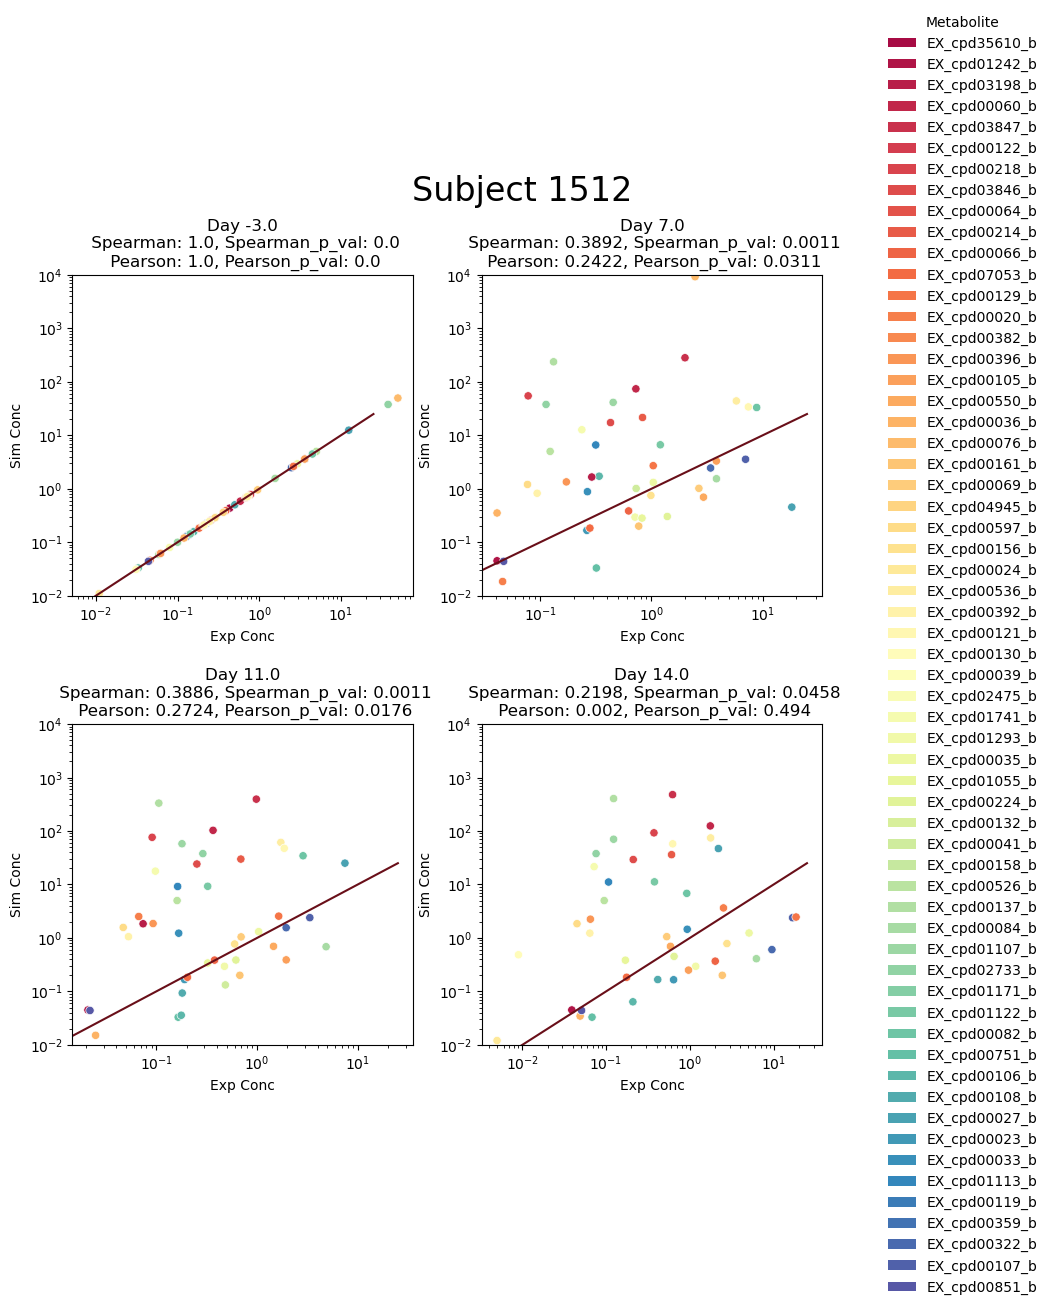

In [75]:
num_plots = 4
cols = 2  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,time in enumerate(merged_exp_sim_met_data['time'].unique().tolist()):
    temp = merged_exp_sim_met_data[merged_exp_sim_met_data['time'] == time]
    
        # Scatter plot on the respective subplot
    sns.scatterplot(ax=axes[i], data=temp, 
                    x=temp['exp_conc'], y=temp['sim_conc'], hue='metabolites', palette=color_map)

    sns.lineplot(ax=axes[i], x=x, y = y)
    temp_pearson = pearsonr(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']), alternative='greater')
    print(temp_pearson.statistic)
    temp_corr = np.corrcoef(temp['exp_conc'], temp['sim_conc'])
    print(temp_corr)
    temp_corr_log = np.corrcoef(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']))
    print(temp_corr_log)
    temp_spearman = spearmanr(np.log1p(temp['exp_conc']), np.log1p(temp['sim_conc']), alternative='greater')
    temp_spearman_stat_round = np.round(temp_spearman.statistic,4)
    temp_spearman_p_val_round = np.round(temp_spearman.pvalue,4)
    temp_pearson_stat_round = np.round(temp_pearson.statistic,4)
    temp_pearson_val_round = np.round(temp_pearson.pvalue,4)
    #axes[i].set_xlim(0,25)
    axes[i].set_ylim(10e-3,10e3)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(f"Day {time}\n Spearman: {temp_spearman_stat_round}, Spearman_p_val: {temp_spearman_p_val_round}\n Pearson: {temp_pearson_stat_round}, Pearson_p_val: {temp_pearson_val_round}")
    axes[i].set_xlabel('Exp Conc')
    axes[i].set_ylabel('Sim Conc')
    axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Add custom legend to the *figure* (not either axis), outside plot
fig.legend(
    handles=legend_elements,
    title='Metabolite',
    loc='center left',
    bbox_to_anchor=(.8, 0.5),  # Push legend just outside right edge
    borderaxespad=0,
    frameon=False,
    ncol=1
)
# Adjust spacing to make room for the legend
plt.subplots_adjust(hspace=.4, right=1)  # Shrink plot width
overall_title = 'Subject ' + str(subject_to_plot)
plt.suptitle(overall_title, x=0.5, fontsize = 24)
plt.subplots_adjust(right=0.75)
plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_scatter_exp_vs_sim_log_scale_' + str(test_num) + '.pdf'
plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()